In [1]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from stoch_sim_model import *

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Define function to run simulations and compute MI

In [2]:
# Make grid
I_0 = 1
b_I = 0.00003
t1 = 10
d_IE = 3.8*10**(-4)
T_I = 2
infection_type = 'sec' #'prim'
cv_param = 0.5
g_NE_max = 4 #0.10 #0.36
g_NM_max = 4 #4 #0.12
g_ME_max = 6.0
g_EM_max = 0.07

runs = 10_000
MI_args = np.hstack(([7],np.arange(10,len(stat_names))))

def comp_MI(param, g_NE, g_NM, g_ME, g_EM):

    params = np.random.lognormal(mean = np.log(param/np.sqrt(1 + cv_param**2)), 
                            sigma = np.sqrt(np.log(1 + cv_param**2)), size = runs)
    # choose which parameter to vary
    run_data = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(params)/8))(delayed(sum_sim)(b_I = param, 
                                                                                                        rates = [b_E_max, b_c1, g_NE, g_NM, g_ME, g_EM],
                                                                                                        infection = infection_type)
                                                    for param in params))
    
    MI_data = np.zeros(len(MI_args))
    for i in np.arange(len(MI_data)):
        MI_data[i] = calc_MI(run_data[:,7], run_data[:,MI_args[i]]) # 0 = a1_0, 1 = b_I
        
    return  np.array(np.append(MI_data, np.mean(run_data[:,10])), dtype=object)


# function to slice data by parameters
extract_stats = np.vectorize(lambda x,stat: x[stat])

v_comp_MI = np.vectorize(comp_MI)

### (2) Maximize MI over $g_{NE}$ and $g_{ME}$

In [3]:
# Create grid of differentiation rates
grid_num = 10
g_NEs, g_MEs = np.meshgrid(np.linspace(0.00*g_NE_max, 2*g_NE_max, grid_num),
                           np.linspace(0.00*g_ME_max, 2*g_ME_max, grid_num))

diff_rates = (np.vstack((np.ravel(g_NEs), np.ravel(g_MEs))).T)

# remove biologically infeasible network architectures
remove_row = np.ones(diff_rates.shape[0], dtype = bool)
# for i in np.arange(diff_rates.shape[0]):
#     if diff_rates[i,0] == 0.0 and diff_rates[i,1] == 0.0:
#         remove_row[i] = False
    
use_diff_rates = (diff_rates[remove_row,...])

In [4]:
# Run simulations
MI_g_NE_g_ME_grid = v_comp_MI(b_I, use_diff_rates[:,0], g_NM_max, use_diff_rates[:,1], g_EM_max)

/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:237: RuntimeWarning: invalid value encountered in double_scalars
  np.where(np.argmax(E) < 1, 0.0, np.max(E)/(np.argmax(E)*dt)), \
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:238: RuntimeWarning: divide by zero encountered in double_scalars
  np.argmax(E)*dt, np.where(np.max(E) < 1.0, 0.0, (eM[-1]+cM[-1])/np.max(E)), np.sum(E*dt), np.sum(np.log(np.maximum(E, E_min))*dt),\
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:237: RuntimeWarning: invalid value encountered in double_scalars
  np.where(np.argmax(E) < 1, 0.0, np.max(E)/(np.argmax(E)*dt)), \
/Users/ObinnaUkogu/Documents/Ac

#### (2a) Plot information transmission as a function of network structure

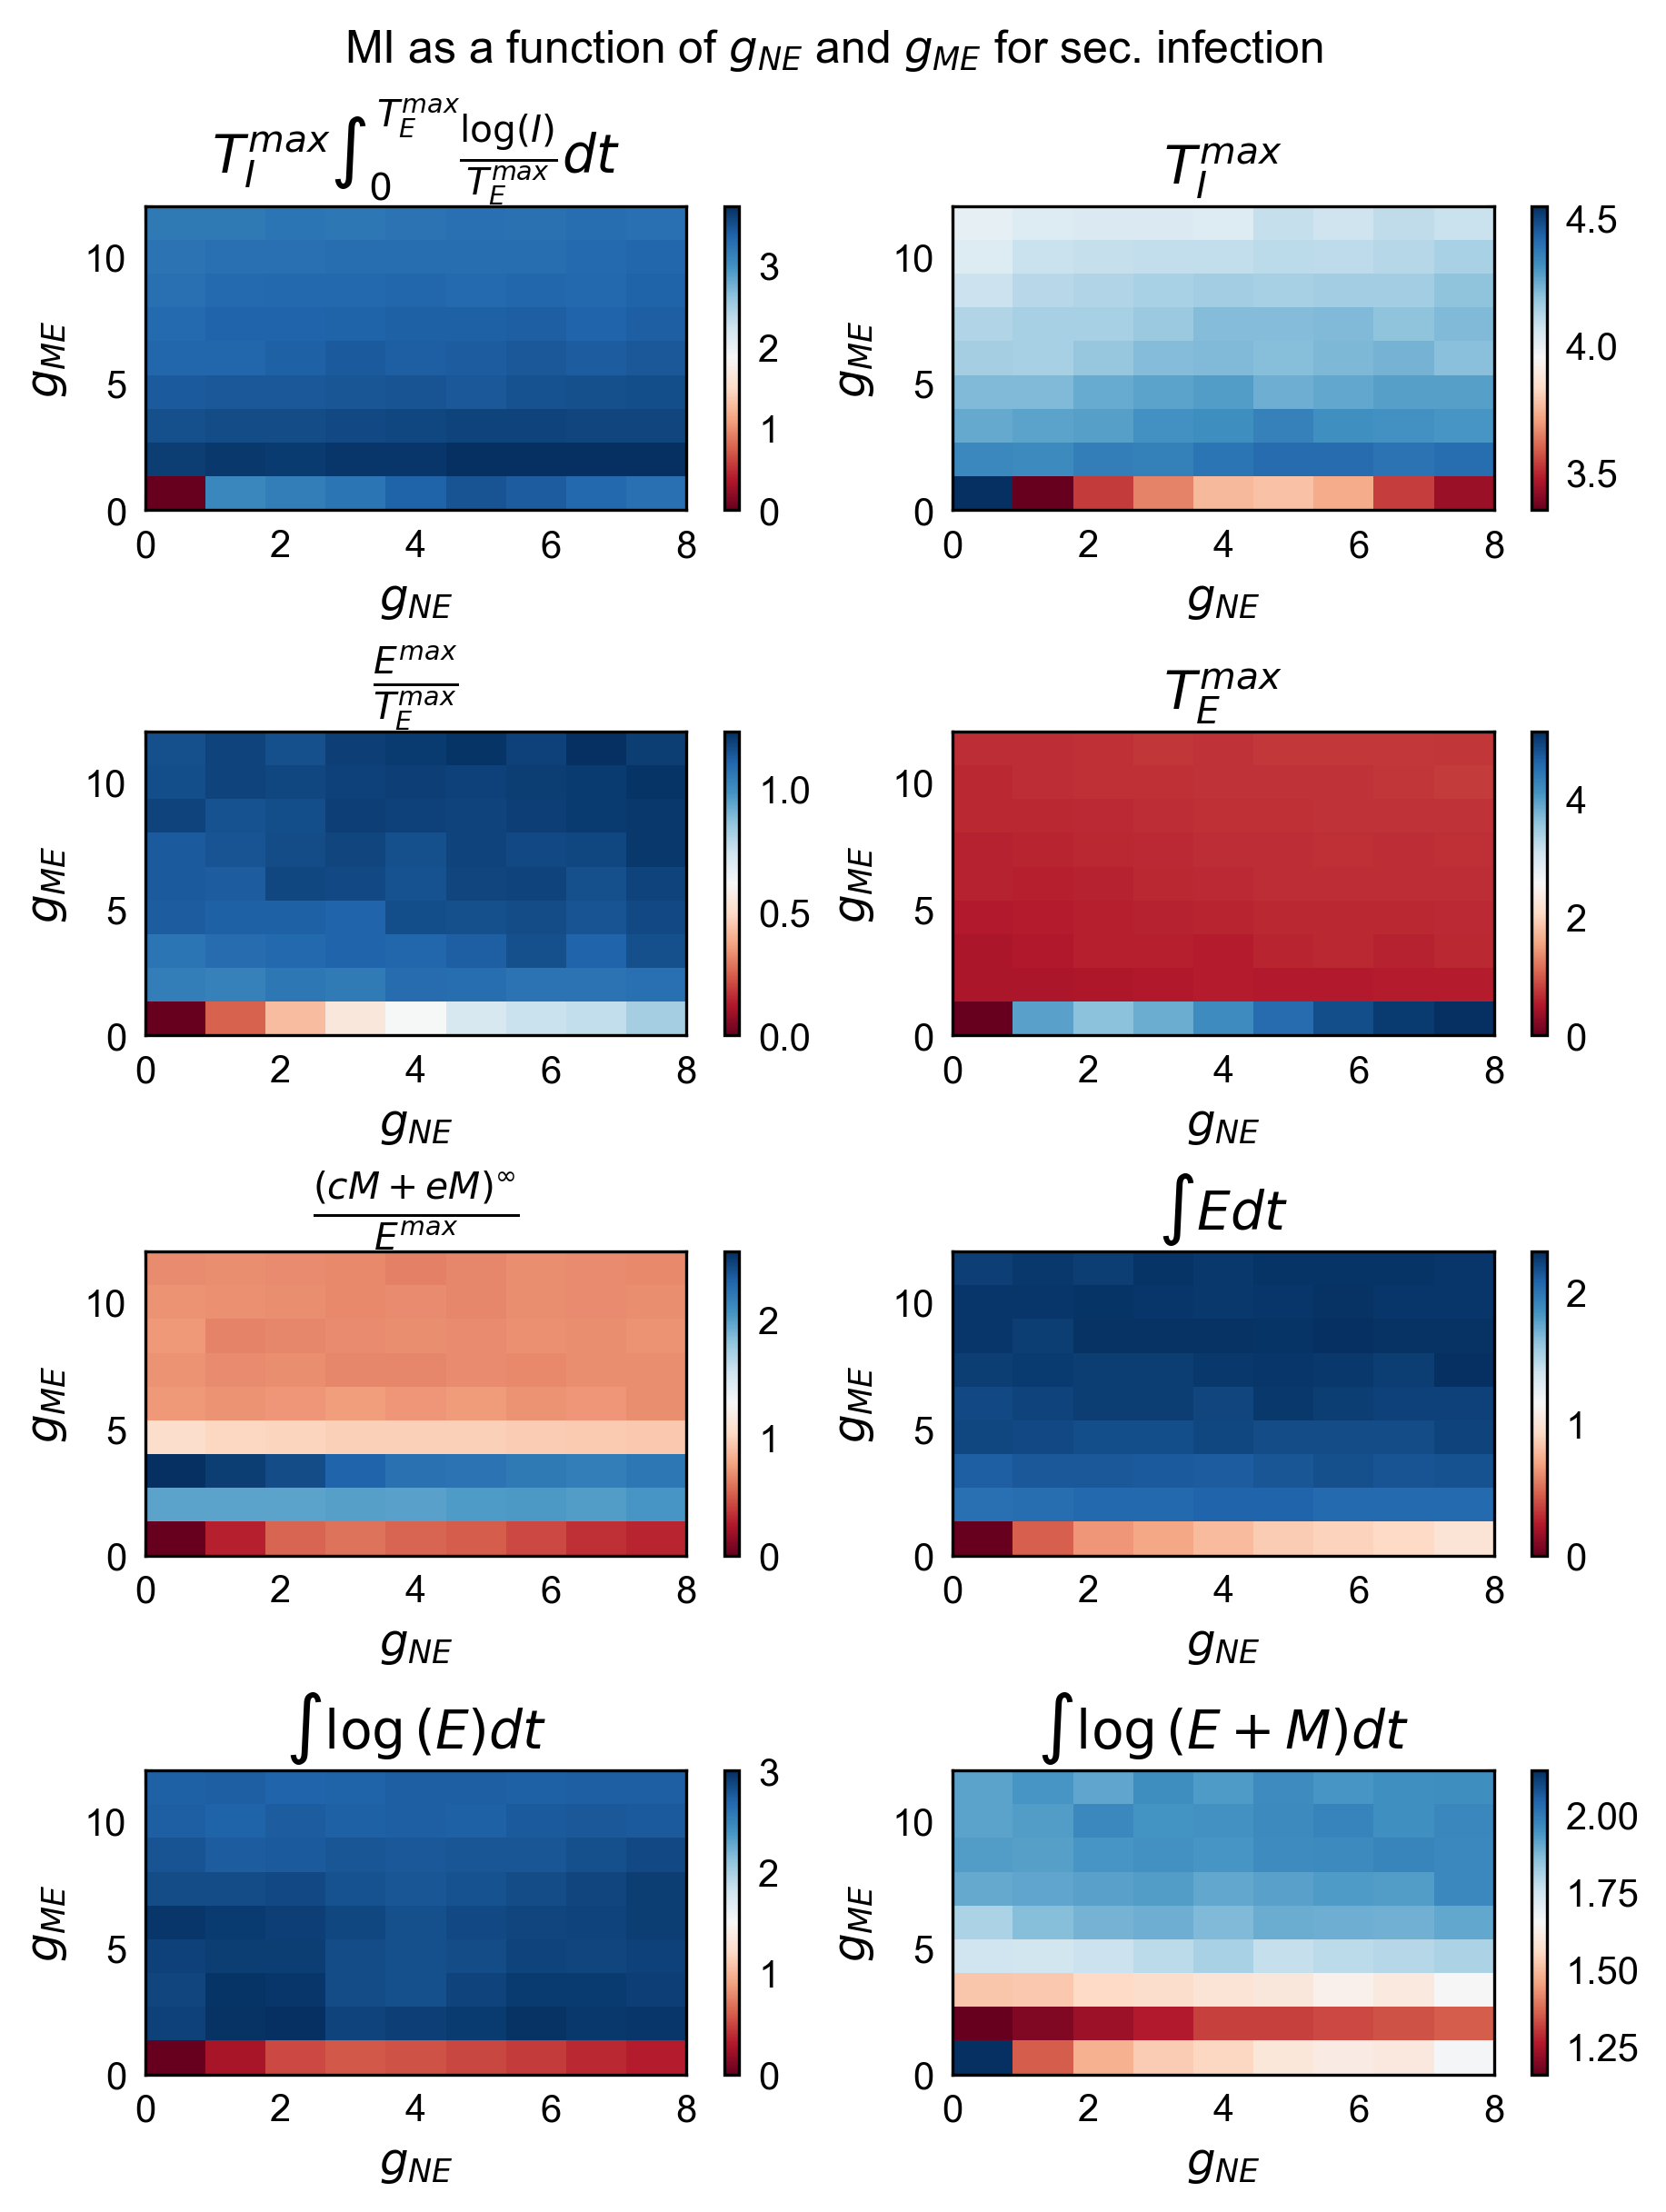

In [5]:
 # plot heat maps
fig_b_I, axs = plt.subplots(4, 2, dpi = 150, constrained_layout = True, figsize = (6,8))
i = 1

for ax, val in zip(axs.flat,stat_names[i+9:]):
    #z = np.append(np.array([0]), extract_stats(MI_g_NE_g_ME_grid,i-3)).reshape((grid_num,grid_num))
    z = extract_stats(MI_g_NE_g_ME_grid,i).reshape((grid_num,grid_num))
    
    z = z[:-1, :-1]
    z_min, z_max = np.abs(z).min(), np.abs(z).max()

    cs = ax.pcolormesh(g_NEs, g_MEs, z, cmap='RdBu', vmin=z_min, vmax=z_max)
    
    ax.set_title(val)
    # set the limits of the plot to the limits of the data
    ax.axis([g_NEs.min(), g_NEs.max(), g_MEs.min(), g_MEs.max()])
    ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{ME}$')
    fig_b_I.colorbar(cs, ax=ax)
        
    i += 1
    
fig_b_I.suptitle(r'MI as a function of $g_{NE}$ and $g_{ME}$'+' for '+infection_type+'. infection')
fig_b_I.savefig(infection_type+'-'+'hmap-MI-vs-g_NE-g_ME.pdf', dpi=300, bbox_inches="tight")

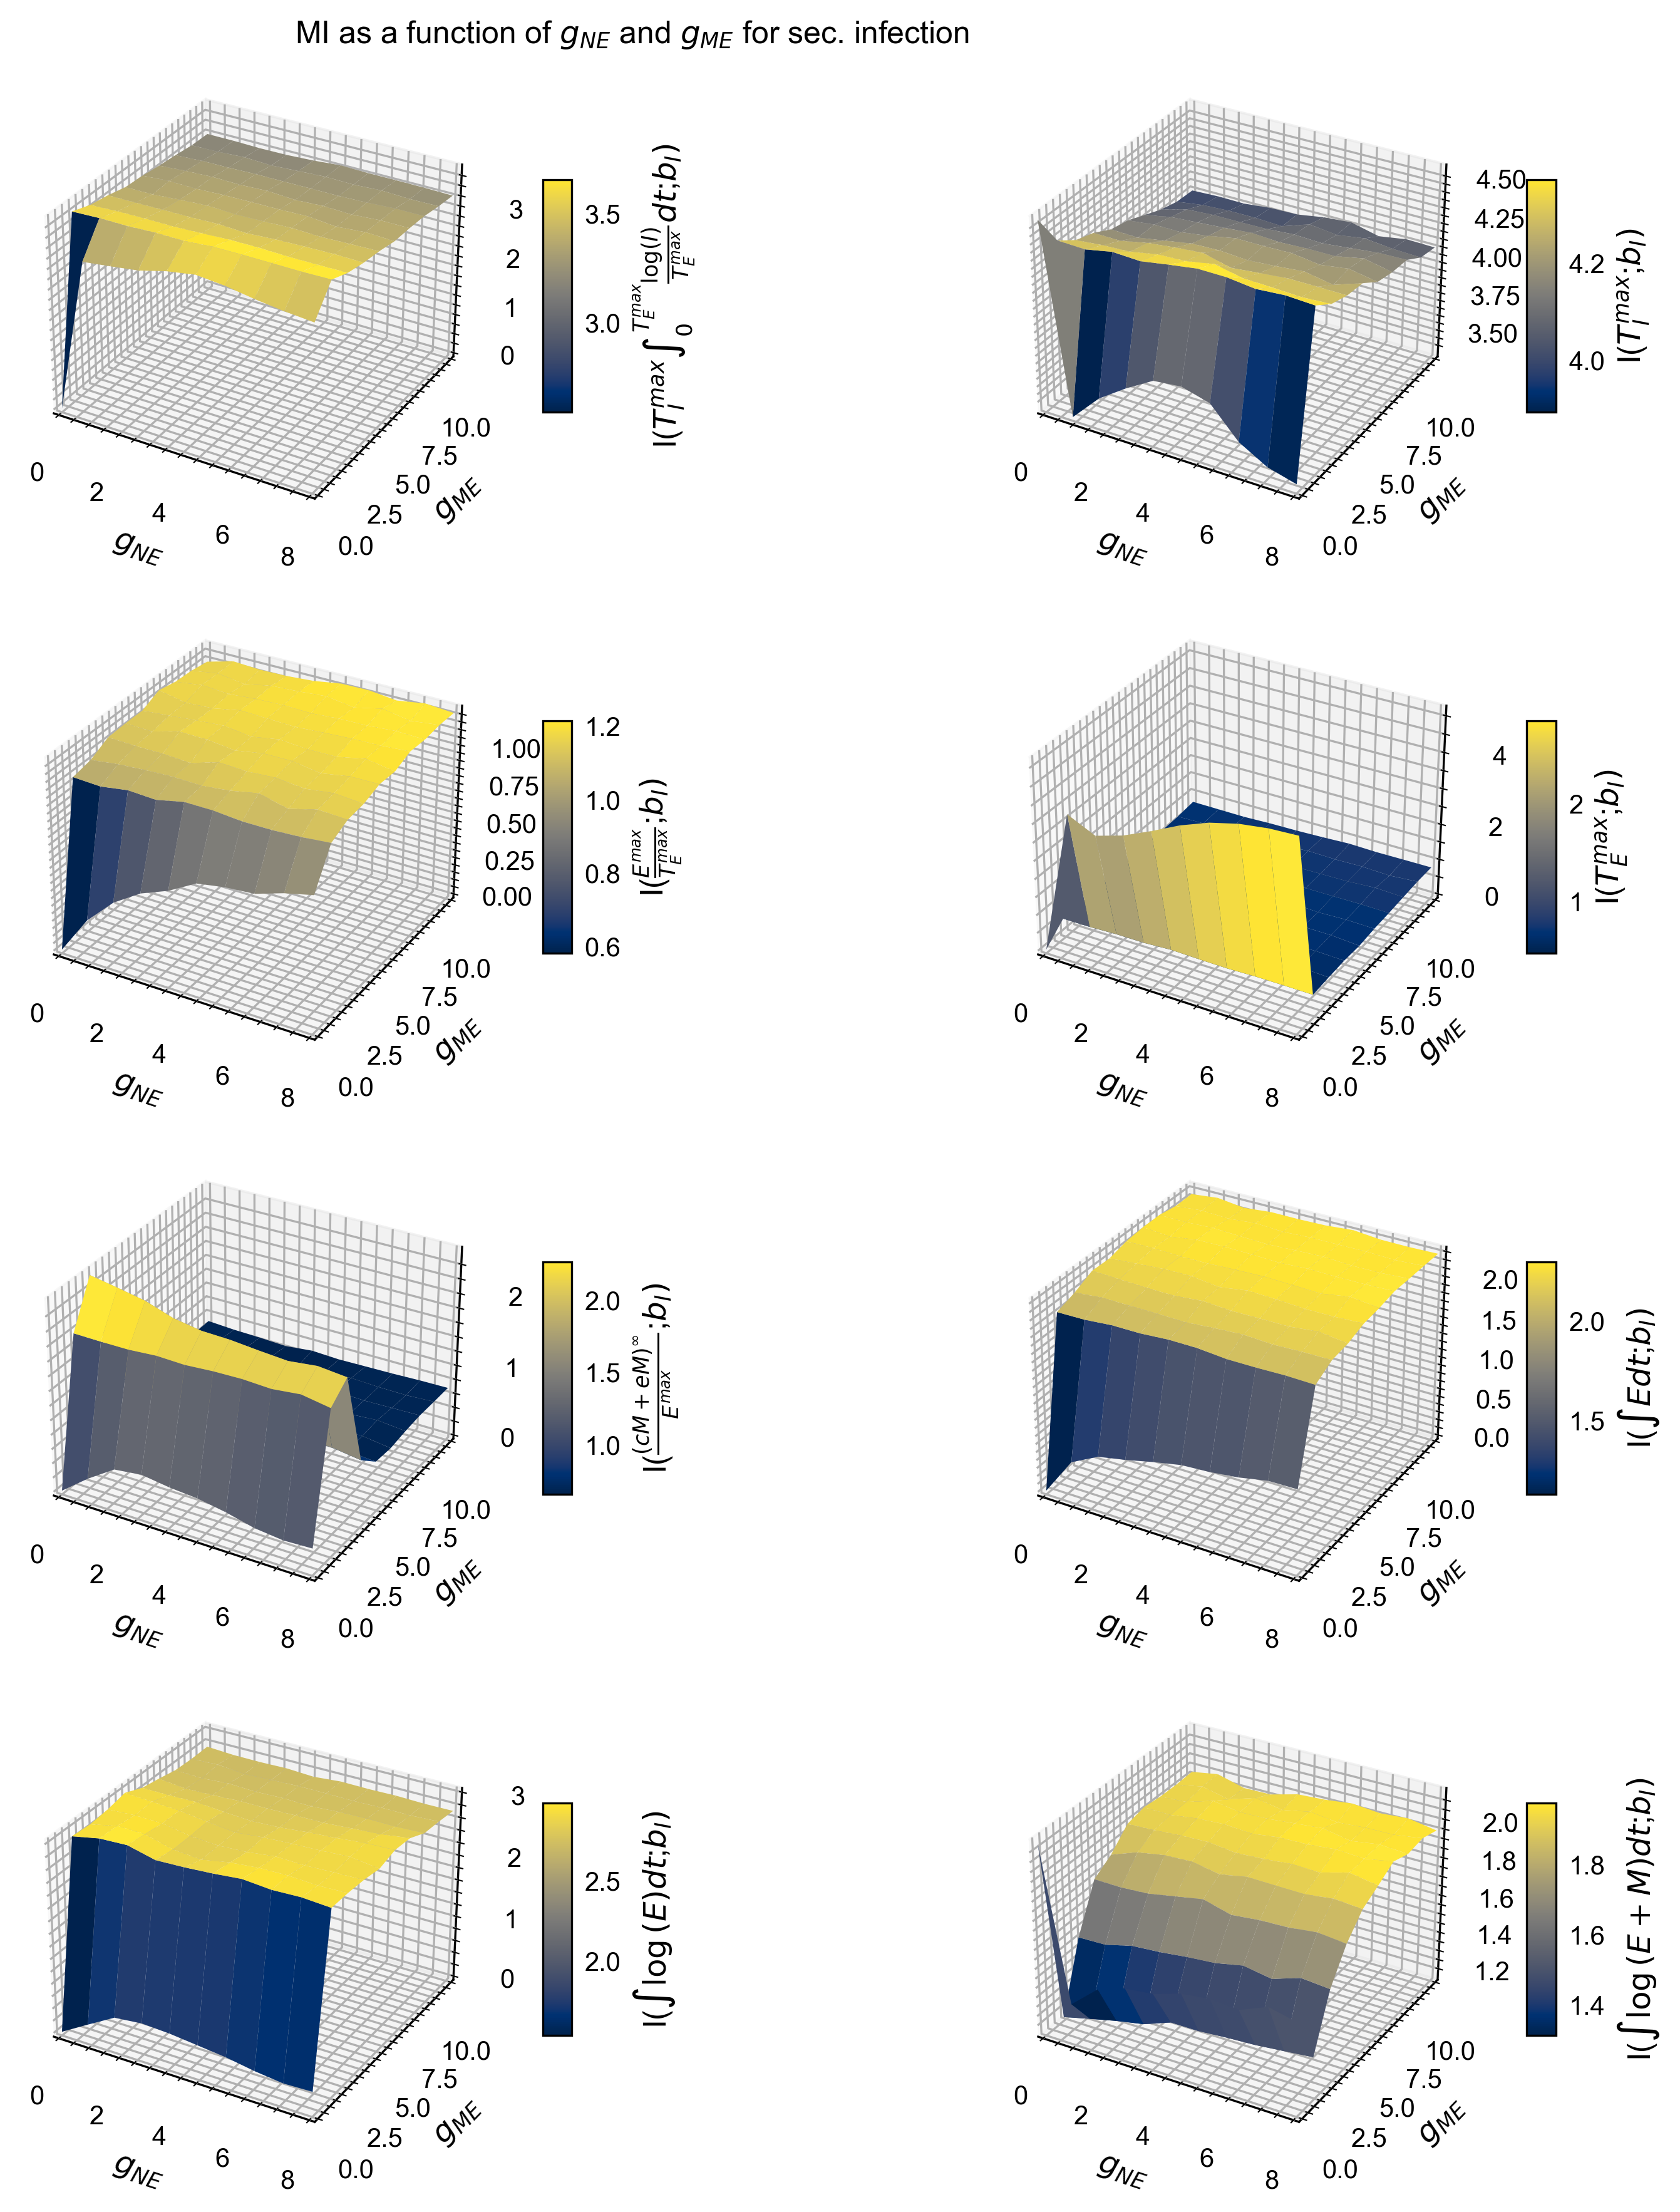

In [6]:
# plot surface plots
fig_b_I = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:
    z = extract_stats(MI_g_NE_g_ME_grid,i).reshape((grid_num,grid_num))

    ax = fig_b_I.add_subplot(4, 2, i, projection='3d')
    cs = ax.plot_surface(g_NEs, g_MEs, z, cmap = plt.cm.cividis)

    #ax.set_title(val)
    # set the limits of the plot to the limits of the data
    ax.axis([g_NEs.min(), g_NEs.max(), g_MEs.min(), g_MEs.max()])
    ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{ME}$')
    fig_b_I.colorbar(cs,  shrink=0.5, aspect=8, label =r"I("+val+r";$b_I)$")

    i += 1
    
fig_b_I.suptitle(r'MI as a function of $g_{NE}$ and $g_{ME}$'+' for '+infection_type+". infection")
fig_b_I.savefig(infection_type+'-'+'surf-MI-vs-g_NE-g_ME.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

#### (2b) Network optimization as a multi-objective optimization (MOO) problem

In [7]:
# # Modified cost function
# fig = plt.figure(figsize = (12,6))
# ax = fig.add_subplot(1,2,1, projection='3d')

# lam = 0.05
# z = np.append(np.array([0]), extract_stats(MI_g_NE_g_ME_grid,-1)).reshape((grid_num,grid_num))
# ax.plot_surface(g_NEs, g_MEs, z, cmap = plt.cm.cividis)
# ax.axis([g_NEs.min(), g_NEs.max(), g_MEs.min(), g_MEs.max()])
# ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{ME}$')

# z = lam*z + np.append(np.array([0]), extract_stats(MI_g_NE_g_ME_grid,-2)).reshape((grid_num,grid_num))

# ax = fig.add_subplot(1,2,2, projection='3d')
# cs = ax.plot_surface(g_NEs, g_MEs, z, cmap = plt.cm.cividis)
# # set the limits of the plot to the limits of the data
# ax.axis([g_NEs.min(), g_NEs.max(), g_MEs.min(), g_MEs.max()])
# ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{ME}$')
# #fig.colorbar(cs,  shrink=0.5, aspect=8, label = stat_names[4])

# fig.suptitle(r'Immune cost as a function of $g_{NE}$ and $g_{ME}$'+' for '+infection_type+". infection")
# plt.tight_layout()

# plt.show()

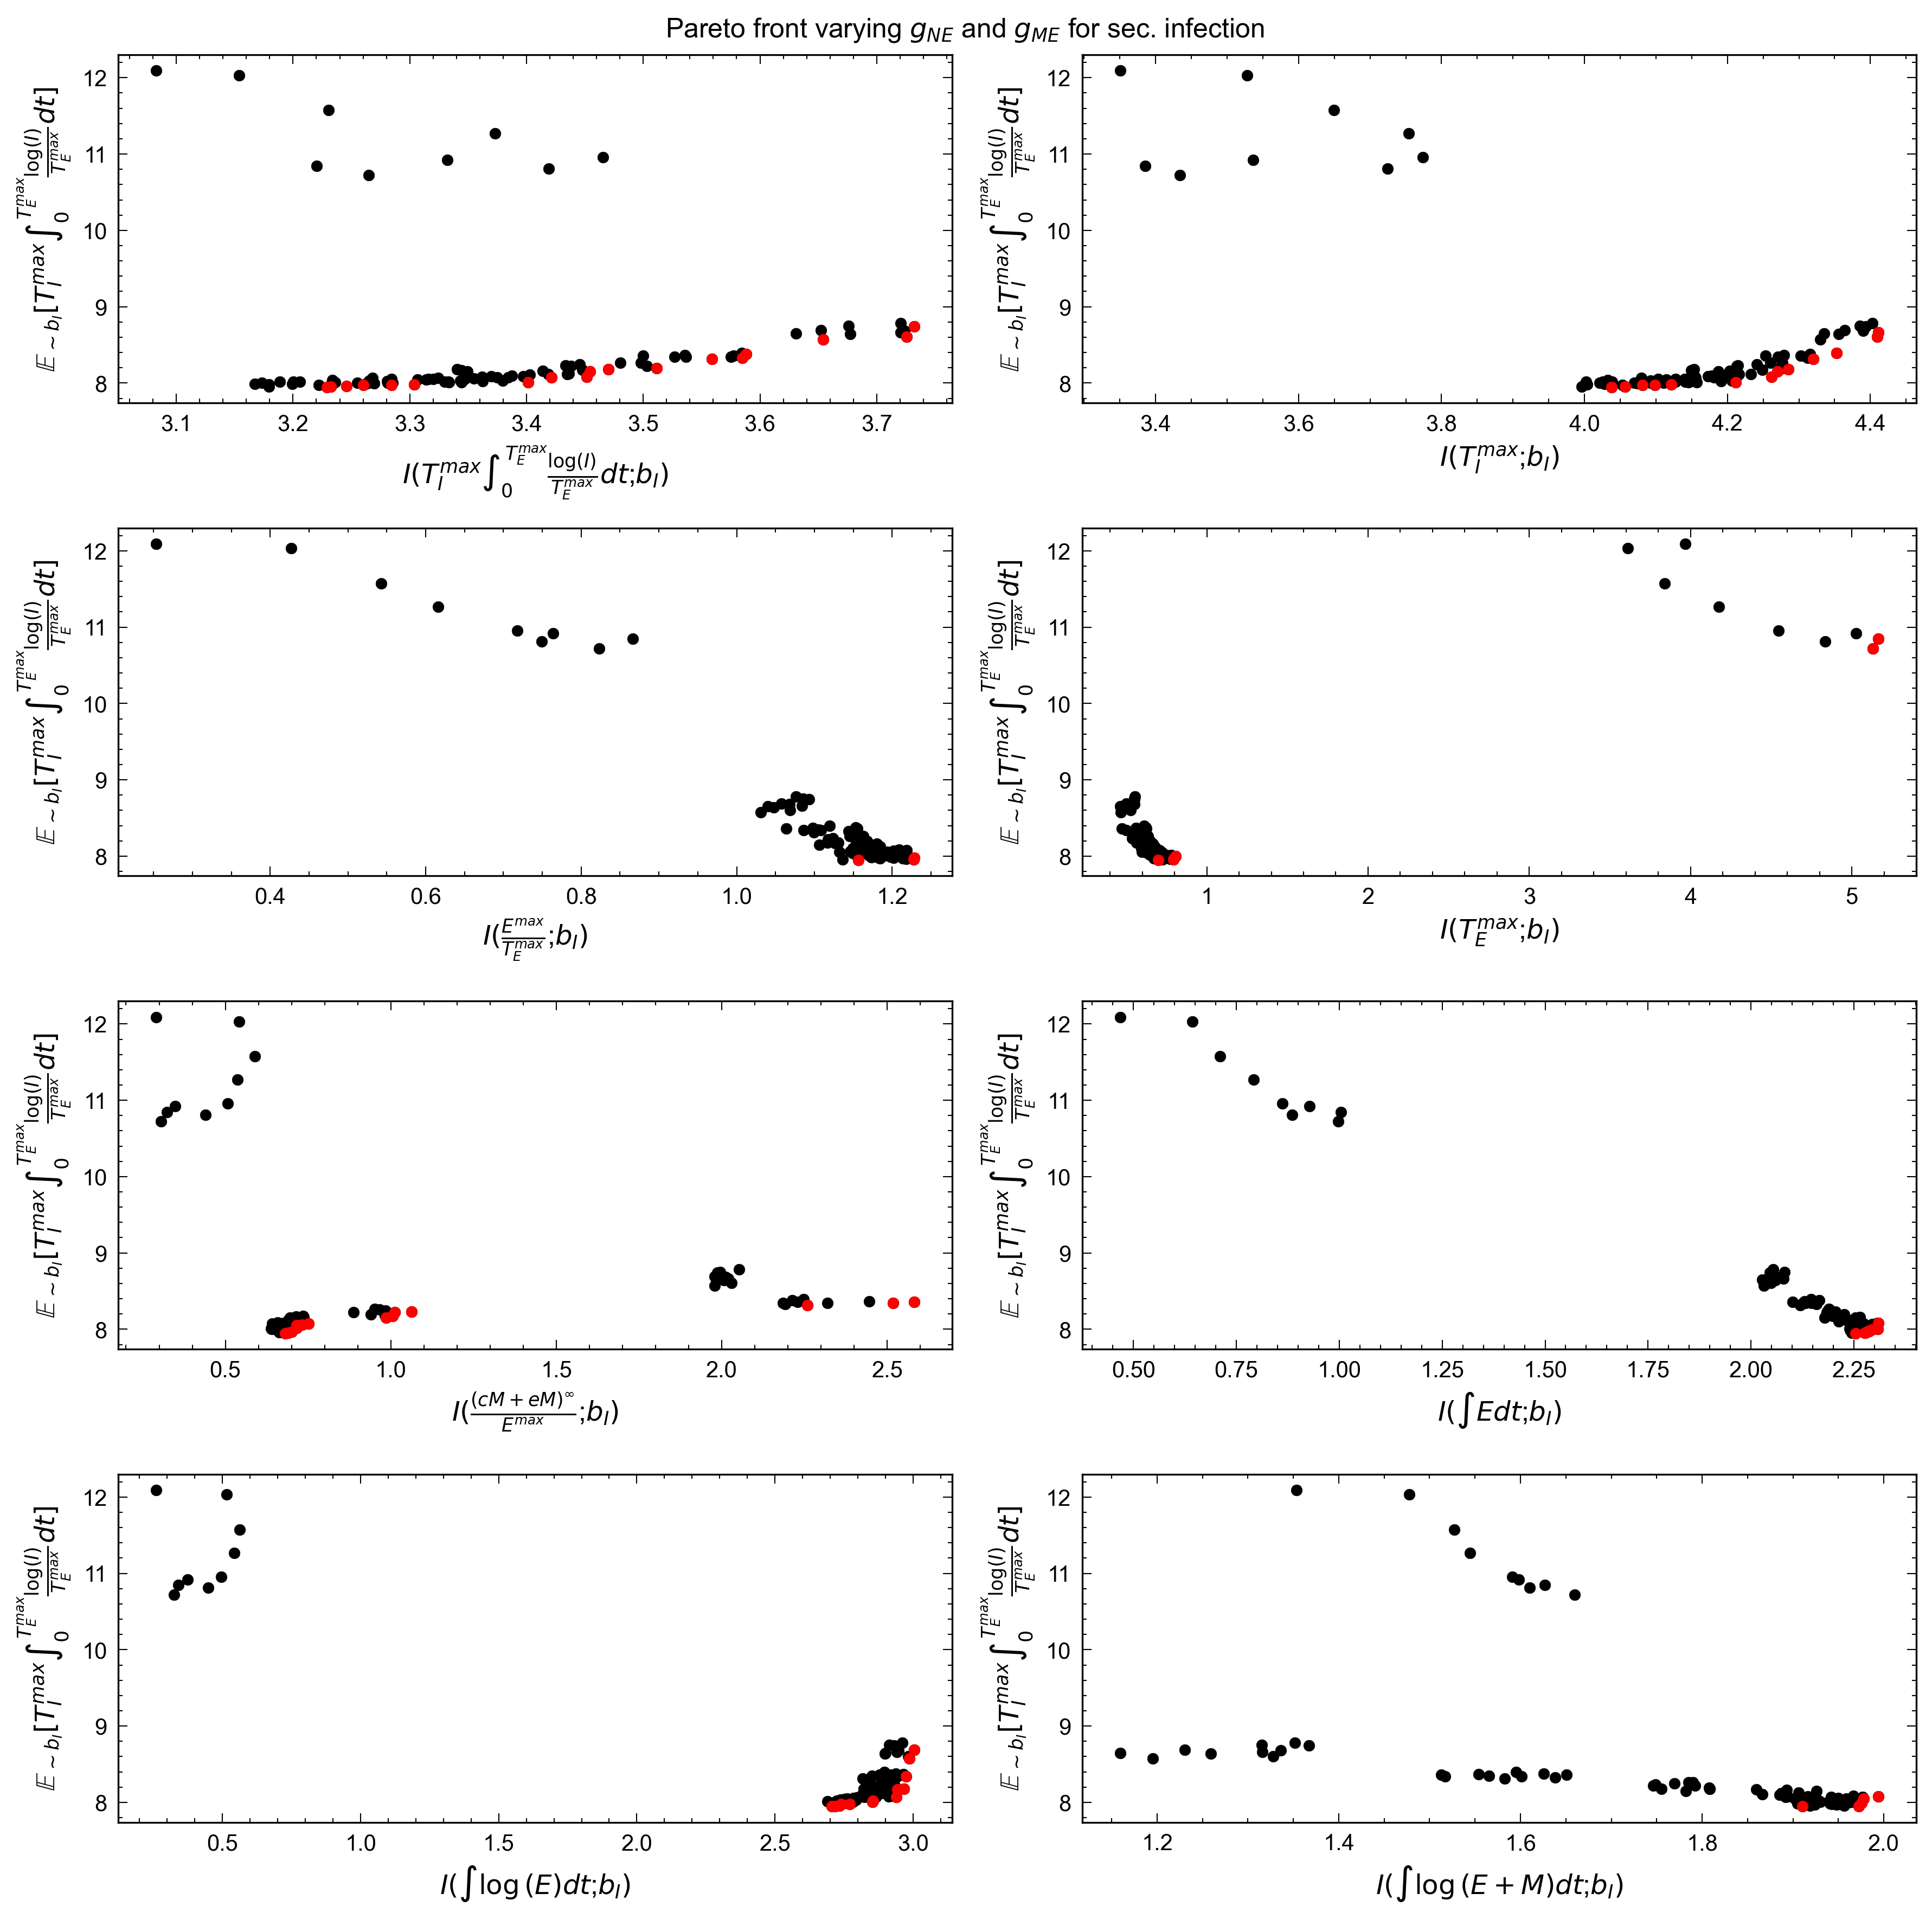

In [8]:
# plot pareto front for appropriateness and effectiveness of the immune response
fig_b_I = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:

    xy = np.array([np.nan_to_num(extract_stats(MI_g_NE_g_ME_grid, i), copy = False) ,
                   np.nan_to_num(extract_stats(MI_g_NE_g_ME_grid, -1), copy = False)]).T
    
    # remove biologically infeasible network architectures
    keep_row = np.ones(xy.shape[0], dtype = bool)
    for k in np.arange(xy.shape[0]):
        if xy[k,-1] == 0.0:
            keep_row[k] = False
            
    xy = (xy[keep_row,...])
    
    # hull = ConvexHull(np.array([x_, y_]).T)
    
    ax = fig_b_I.add_subplot(4, 2, i)
    cs = ax.plot(xy[:,0], xy[:,1], 'ko')
    
    # find pareto front
    keep_row = np.ones(xy.shape[0], dtype = bool)
    
    for j in np.arange(len(xy[:,0])):
        for k in np.arange(len(xy[:,0])):
            if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
                keep_row[j] = False
    
    x_front = (xy[:,0])[keep_row,...]
    y_front = (xy[:,1])[keep_row,...]
    ax.plot(x_front, y_front, 'ro')

    # set the limits of the plot to the limits of the data
    ax.set(xlabel=r"$I($"+val+r";$b_I)$", ylabel=r"$\mathbb{E}_{\sim b_I}[$"+stat_names[10]+r"$]$")

    i += 1
    
fig_b_I.suptitle(r'Pareto front varying $g_{NE}$ and $g_{ME}$'+' for '+infection_type+". infection")
fig_b_I.savefig(infection_type+'-pareto-g_NE-g_ME.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

In [9]:
# # Match networks with MI outputs
# MI_g_NE_g_ME_data = np.zeros((len(MI_g_NE_g_ME_grid),len(MI_g_NE_g_ME_grid[0])))

# for i in np.arange(len(MI_g_NE_g_ME_grid)):
#     MI_g_NE_g_ME_data[i,:] = MI_g_NE_g_ME_grid[i].astype(float)

In [10]:
# # Optimize over network architectures
# network_MI_g_NE_g_ME = np.append(use_diff_rates, MI_g_NE_g_ME_data[:,4:], axis = 1)

# # #np.save('optimize-nets.npy',network_MI)
# for i in np.arange(4,len(stat_names)):
#     max_val = network_MI_g_NE_g_ME[network_MI_g_NE_g_ME[:,i].argmax()]
#     print("MI for " + stat_names[i]+" is maximized ("+str(max_val[i])+") by the network with: "+str(max_val[:4]))
    
# # # with np.printoptions(suppress = True, linewidth = 200, threshold=np.inf):
# # #     print(network_MI[(-network_MI[:, -1]).argsort()])

### (3) Maximize MI over $g_{NE}$ and $g_{NM}$

In [11]:
# Create grid of differentiation rates
grid_num = 10
g_NEs, g_NMs = np.meshgrid(np.linspace(0.00*g_NE_max, 2*g_NE_max, grid_num),
                           np.linspace(0.00*g_NM_max, 2*g_NM_max, grid_num))

diff_rates = (np.vstack((np.ravel(g_NEs), np.ravel(g_NMs))).T)

# remove biologically infeasible network architectures
remove_row = np.ones(diff_rates.shape[0], dtype = bool)
# for i in np.arange(diff_rates.shape[0]):
#     if diff_rates[i,0] == 0.0 and diff_rates[i,1] == 0.0:
#         remove_row[i] = False
    
use_diff_rates = (diff_rates[remove_row,...])

In [12]:
# Run simulations
MI_g_NE_g_NM_grid = v_comp_MI(b_I, use_diff_rates[:,0], use_diff_rates[:,1], g_ME_max, g_EM_max)

/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:238: RuntimeWarning: invalid value encountered in double_scalars
  np.argmax(E)*dt, np.where(np.max(E) < 1.0, 0.0, (eM[-1]+cM[-1])/np.max(E)), np.sum(E*dt), np.sum(np.log(np.maximum(E, E_min))*dt),\
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:238: RuntimeWarning: invalid value encountered in double_scalars
  np.argmax(E)*dt, np.where(np.max(E) < 1.0, 0.0, (eM[-1]+cM[-1])/np.max(E)), np.sum(E*dt), np.sum(np.log(np.maximum(E, E_min))*dt),\
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:238: RuntimeWarning: invalid value encountered in double_scalars
  np.argmax(E)*dt, np.where(np

#### (3a) Plot information transmission as a function of network structure

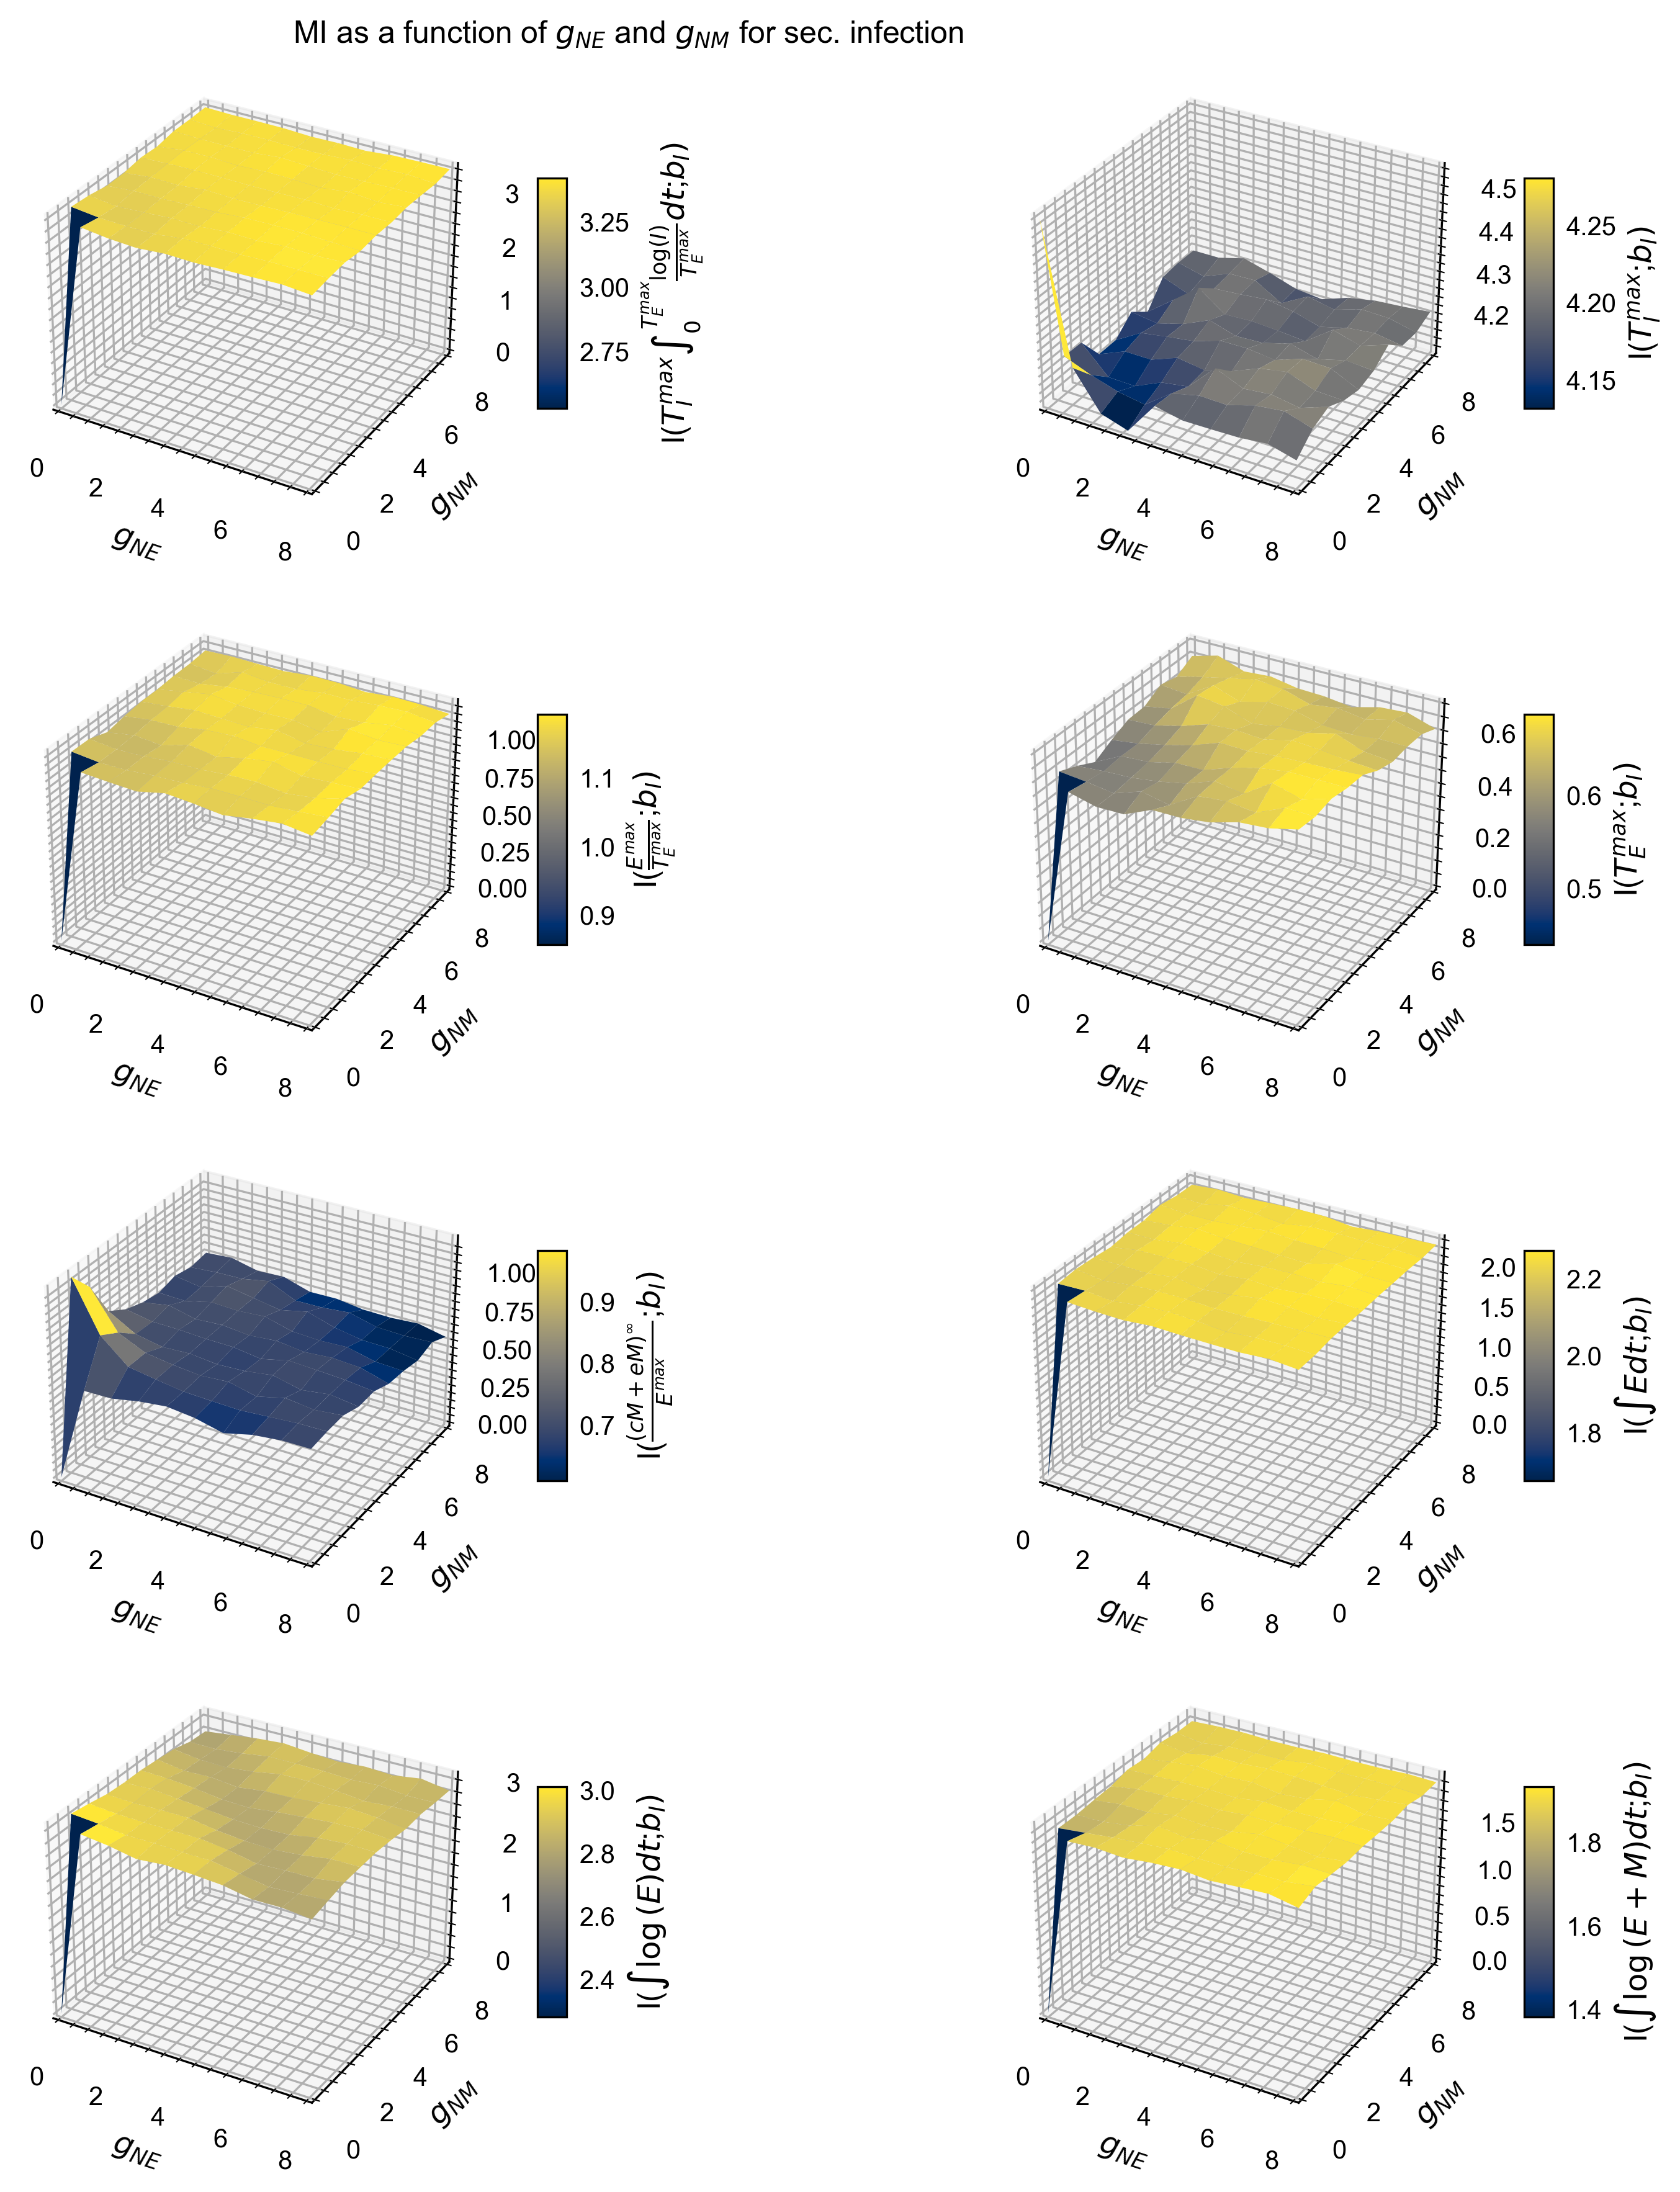

In [13]:
# plot surface maps
fig_b_I_g_NE_g_NM = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:
    z = extract_stats(MI_g_NE_g_NM_grid,i).reshape((grid_num,grid_num))

    ax = fig_b_I_g_NE_g_NM.add_subplot(4, 2, i, projection='3d')
    cs = ax.plot_surface(g_NEs, g_NMs, z, cmap = plt.cm.cividis)

    #ax.set_title(val, fontsize = 8)
    # set the limits of the plot to the limits of the data
    ax.axis([g_NEs.min(), g_NEs.max(), g_NMs.min(), g_NMs.max()])
    ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{NM}$')
    fig_b_I_g_NE_g_NM.colorbar(cs,  shrink=0.5, aspect=8, label =r"I("+val+r";$b_I)$")

    i += 1
    
fig_b_I_g_NE_g_NM.suptitle(r'MI as a function of $g_{NE}$ and $g_{NM}$'+' for '+infection_type+". infection")
fig_b_I_g_NE_g_NM.savefig(infection_type+'-'+'surf-MI-vs-g_NE-g_NM.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

#### (3b) Network optimization as a multi-objective optimization (MOO) problem

In [14]:
# # Modified cost function
# fig = plt.figure(figsize = (12,6))
# ax = fig.add_subplot(1,2,1, projection='3d')

# lam = 0.05
# z = np.append(np.array([0]), extract_stats(MI_g_NE_g_NM_grid,-1)).reshape((grid_num,grid_num))
# ax.plot_surface(g_NEs, g_NMs, z, cmap = plt.cm.cividis)
# ax.axis([g_NEs.min(), g_NEs.max(), g_NMs.min(), g_NMs.max()])
# ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{NM}$')

# z = lam*z + np.append(np.array([0]), extract_stats(MI_g_NE_g_NM_grid,-2)).reshape((grid_num,grid_num))

# ax = fig.add_subplot(1,2,2, projection='3d')
# cs = ax.plot_surface(g_NEs, g_NMs, z, cmap = plt.cm.cividis)
# # set the limits of the plot to the limits of the data
# ax.axis([g_NEs.min(), g_NEs.max(), g_NMs.min(), g_NMs.max()])
# ax.set(xlabel=r'$g_{NE}$', ylabel=r'$g_{NM}$')
# #fig.colorbar(cs,  shrink=0.5, aspect=8, label = stat_names[4])

# fig.suptitle('Immune cost as a function of $g_{NE}$ and $g_{NM}$'+' for '+infection_type+". infection")
# plt.tight_layout()

# plt.show()

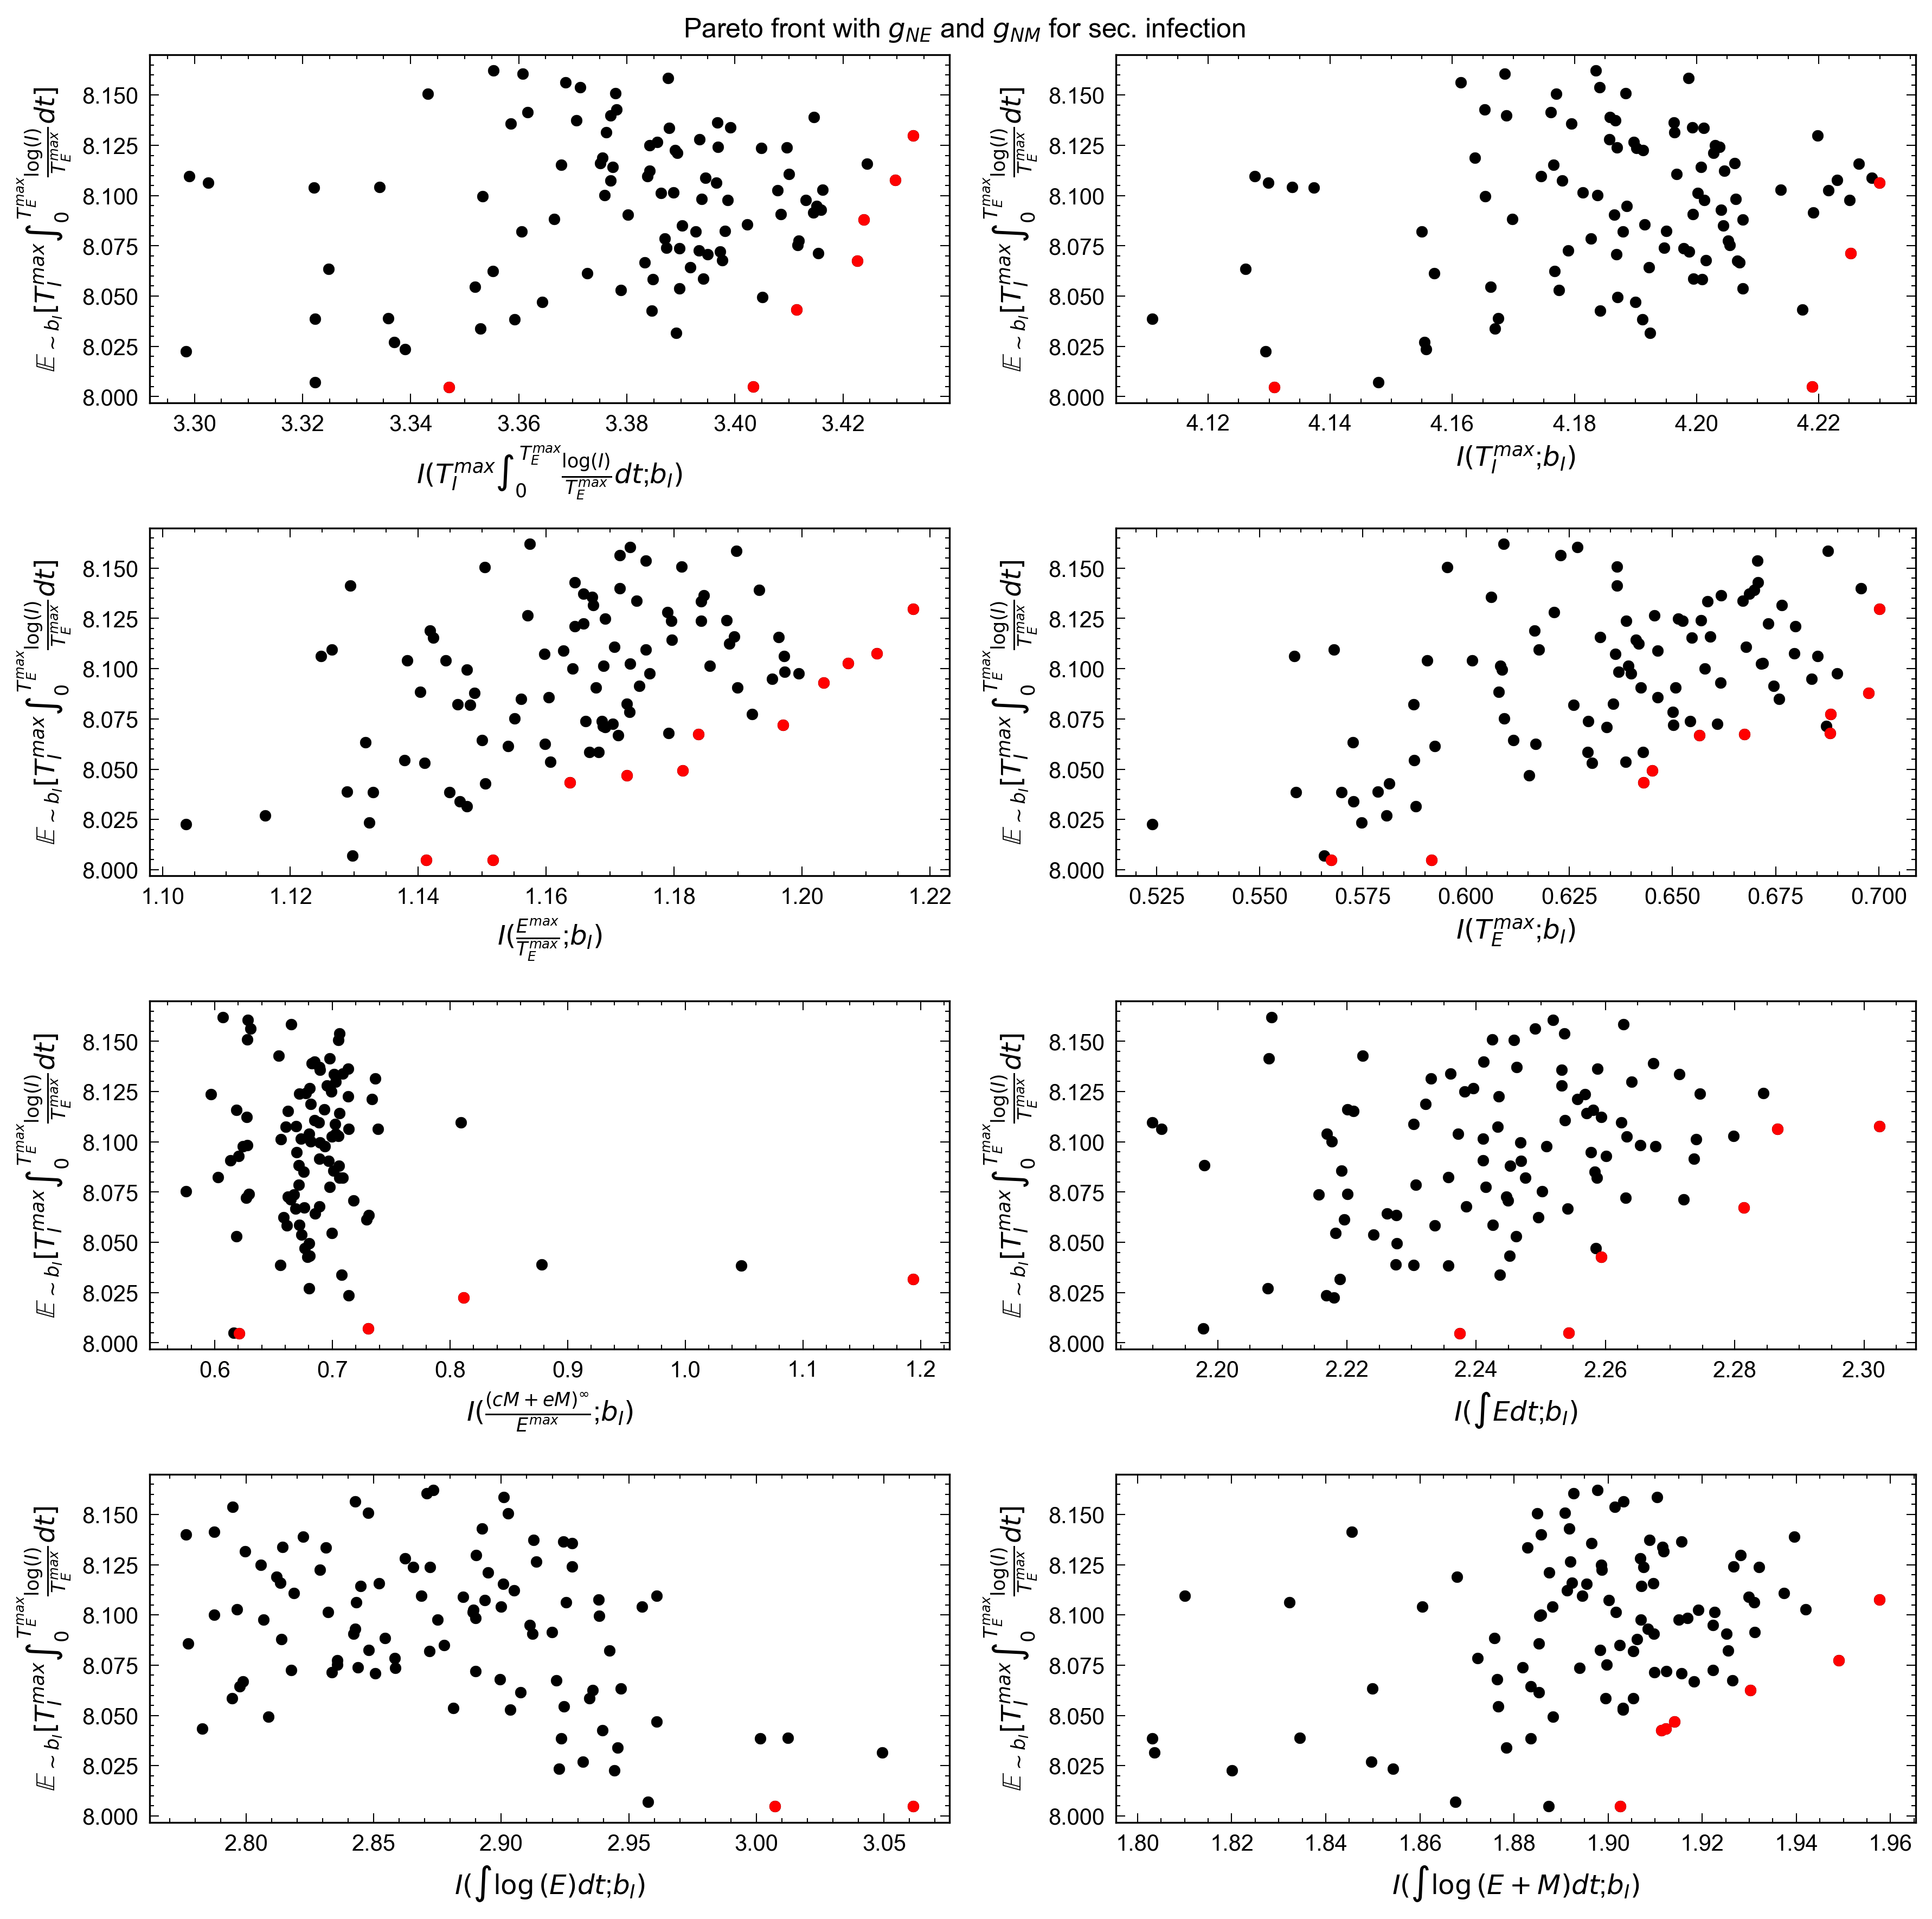

In [15]:
# plot pareto front for appropriateness and effectiveness of the immune response
fig_b_I = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:

    xy = np.array([np.nan_to_num(extract_stats(MI_g_NE_g_NM_grid, i), copy = False) ,
                   np.nan_to_num(extract_stats(MI_g_NE_g_NM_grid, -1), copy = False)]).T
    
     # remove biologically infeasible network architectures
    keep_row = np.ones(xy.shape[0], dtype = bool)
    for k in np.arange(xy.shape[0]):
        if xy[k,-1] == 0.0:
            keep_row[k] = False
            
    xy = (xy[keep_row,...])
    
    # hull = ConvexHull(np.array([x_, y_]).T)
    
    ax = fig_b_I.add_subplot(4, 2, i)
    cs = ax.plot(xy[:,0], xy[:,1], 'ko')
    
    # find pareto front
    remove_row = np.ones(xy.shape[0], dtype = bool)
    
    for j in np.arange(len(xy[:,0])):
        for k in np.arange(len(xy[:,0])):
            if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
                remove_row[j] = False
                
    
    x_front = (xy[:,0])[remove_row,...]
    y_front = (xy[:,1])[remove_row,...]
    ax.plot(x_front, y_front, 'ro')

    # set the limits of the plot to the limits of the data
    ax.set(xlabel=r"$I($"+val+r";$b_I)$", ylabel=r"$\mathbb{E}_{\sim b_I}[$"+stat_names[10]+r"$]$")

    i += 1
    
fig_b_I.suptitle(r'Pareto front with $g_{NE}$ and $g_{NM}$'+' for '+infection_type+". infection")
fig_b_I.savefig(infection_type+'-pareto-g_NE-g_NM.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

### (4) Maximize MI over $g_{NM}$ and $g_{EM}$

In [16]:
# Create grid of differentiation rates
grid_num = 10
g_NMs, g_EMs = np.meshgrid(np.linspace(0.00*g_NM_max, 2*g_NM_max, grid_num),
                           np.linspace(0.00*g_EM_max, 2*g_EM_max, grid_num))

diff_rates = (np.vstack((np.ravel(g_NMs), np.ravel(g_EMs))).T)

# remove biologically infeasible network architectures
remove_row = np.ones(diff_rates.shape[0], dtype = bool)
# for i in np.arange(diff_rates.shape[0]):
#     if diff_rates[i,0] == 0.0 and diff_rates[i,1] == 0.0:
#         remove_row[i] = False
    
use_diff_rates = (diff_rates[remove_row,...])

In [17]:
# Run simulations
MI_g_NM_g_EM_grid = v_comp_MI(b_I, g_NE_max, use_diff_rates[:,0],  g_ME_max, use_diff_rates[:,1])

#### (4a) Plot information transmission as a function of network structure

#### (4b) Network optimization as a multi-objective optimization (MOO) problem

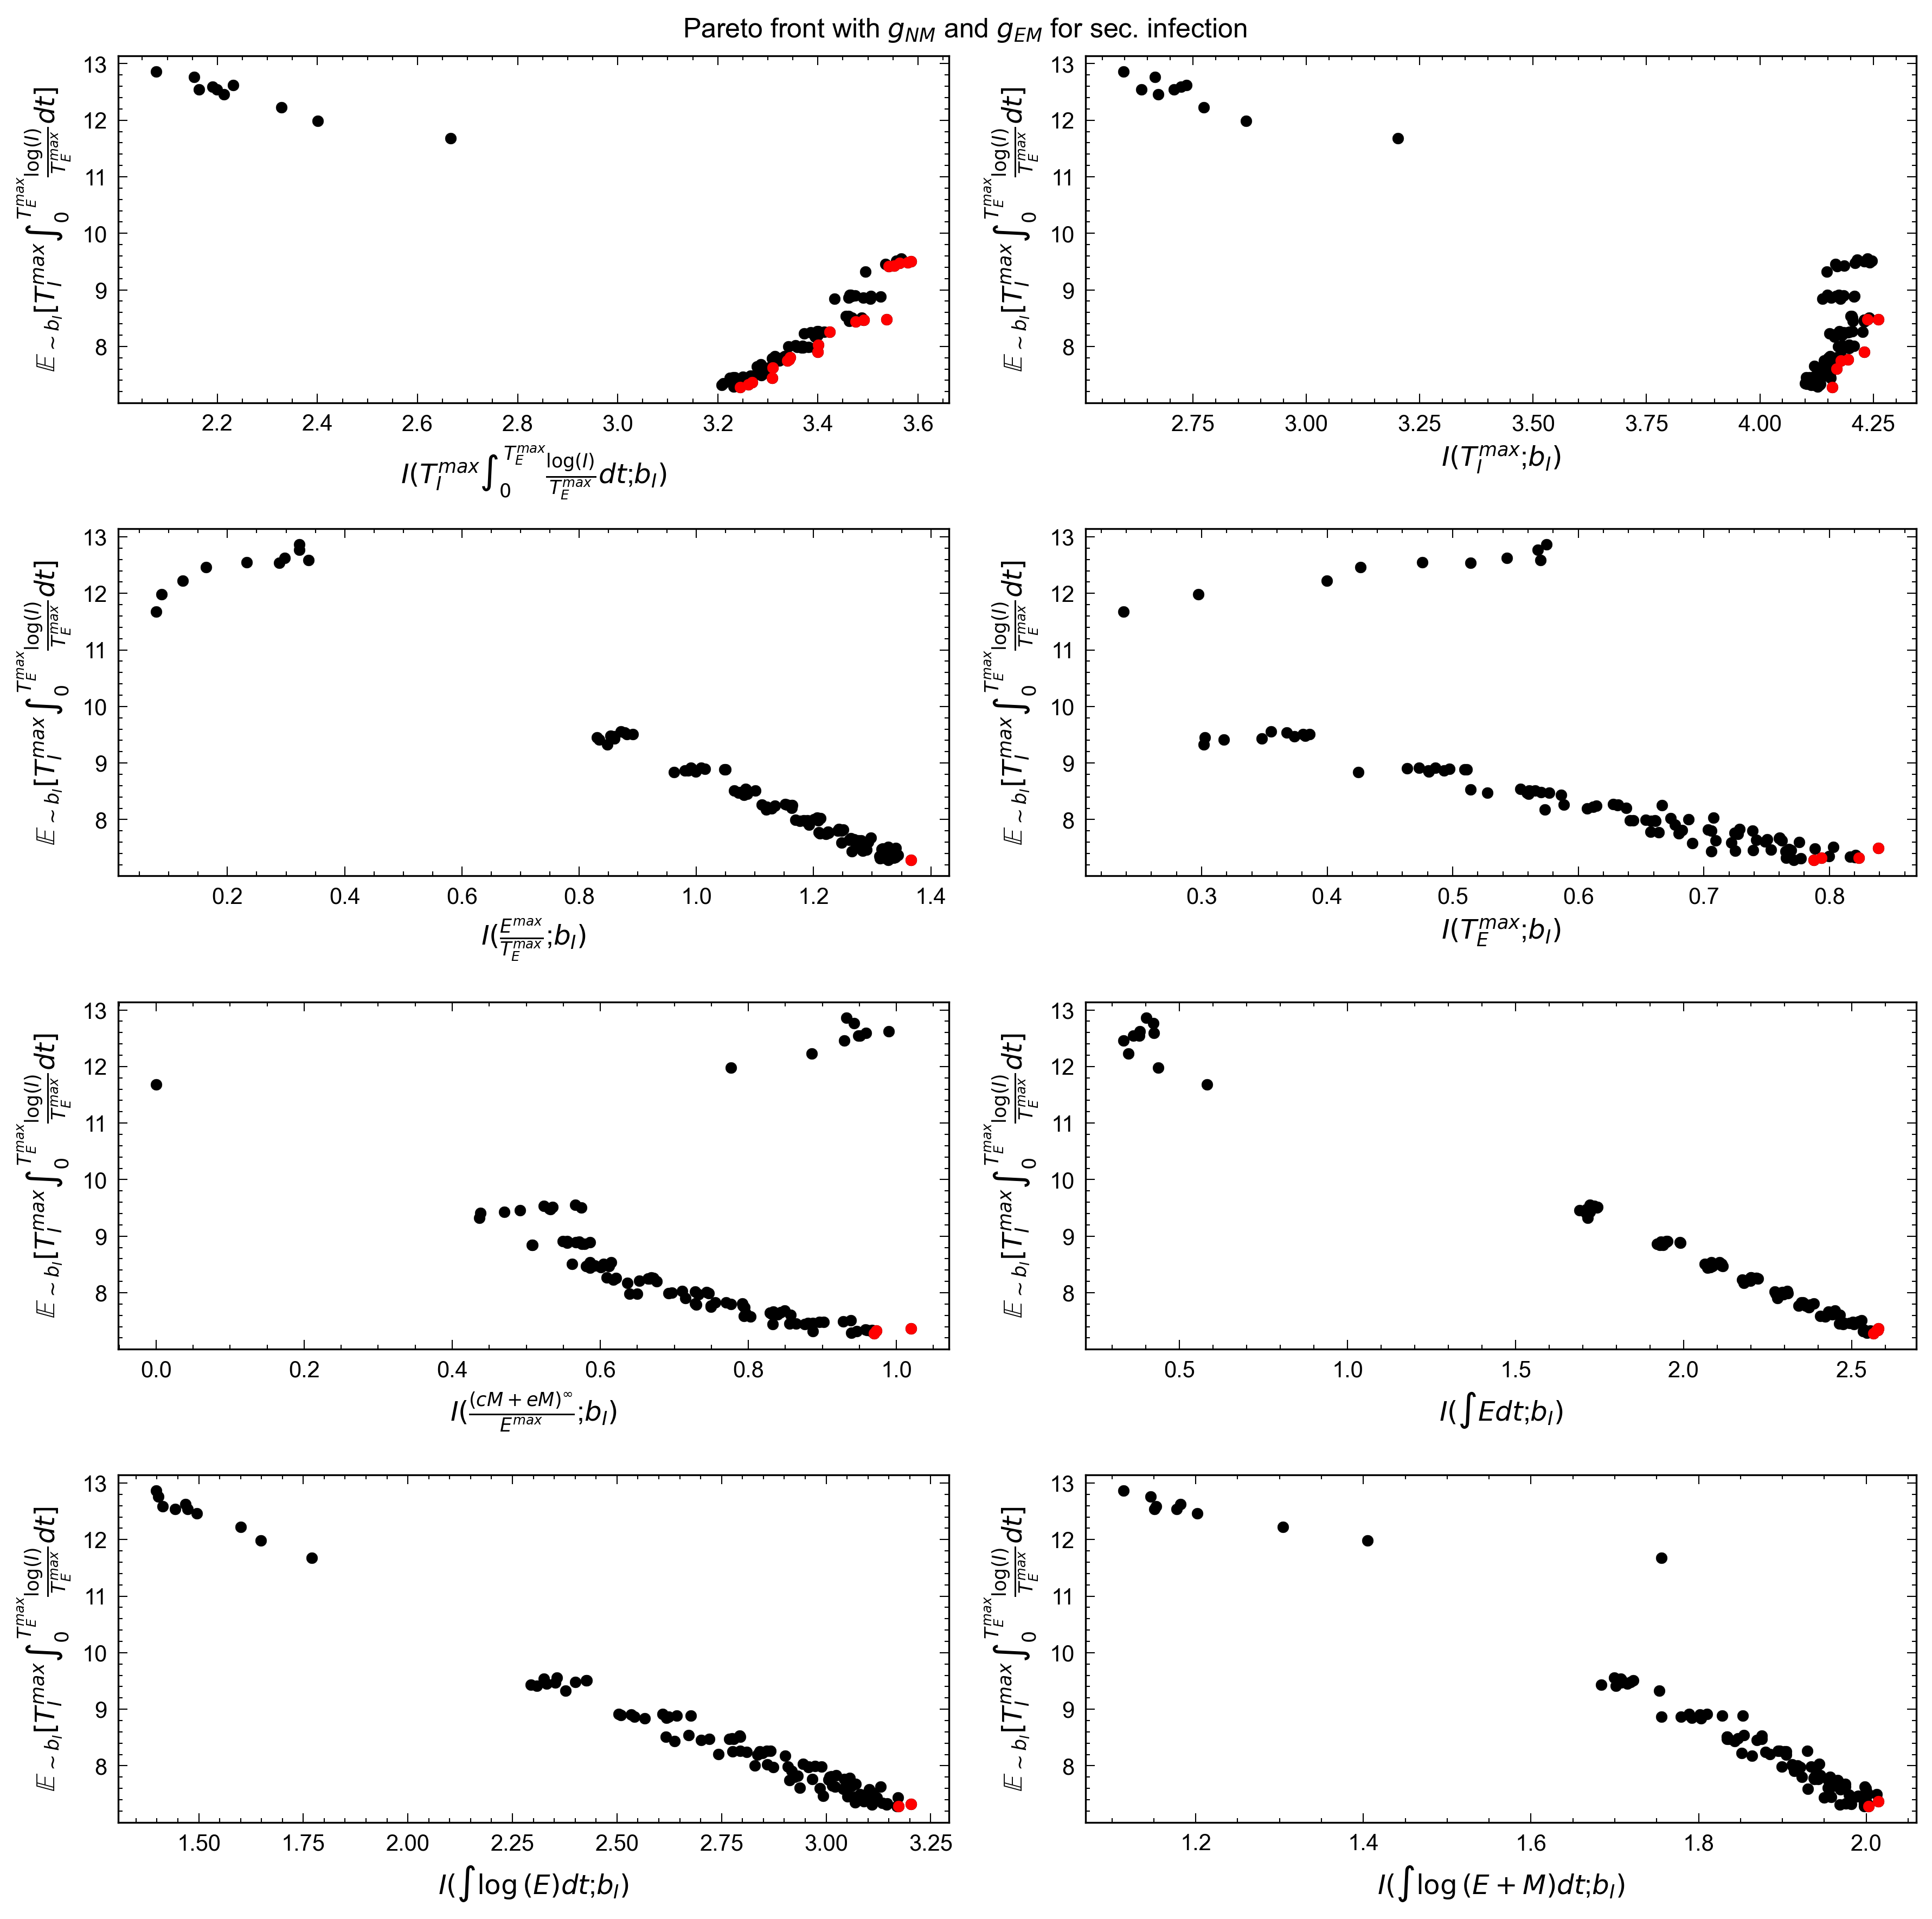

In [19]:
# plot pareto front for appropriateness and effectiveness of the immune response
fig_b_I = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:

    xy = np.array([np.nan_to_num(extract_stats(MI_g_NM_g_EM_grid, i), copy = False) ,np.nan_to_num(extract_stats(MI_g_NM_g_EM_grid, -1), copy = False)]).T
    
     # remove biologically infeasible network architectures
    keep_row = np.ones(xy.shape[0], dtype = bool)
    for k in np.arange(xy.shape[0]):
        if xy[k,-1] == 0.0:
            keep_row[k] = False
            
    xy = (xy[keep_row,...])
    
    # hull = ConvexHull(np.array([x_, y_]).T)
    
    ax = fig_b_I.add_subplot(4, 2, i)
    cs = ax.plot(xy[:,0], xy[:,1], 'ko')
    
    # find pareto front
    remove_row = np.ones(xy.shape[0], dtype = bool)
    
    for j in np.arange(len(xy[:,0])):
        for k in np.arange(len(xy[:,0])):
            if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
                remove_row[j] = False
                
    
    x_front = (xy[:,0])[remove_row,...]
    y_front = (xy[:,1])[remove_row,...]
    ax.plot(x_front, y_front, 'ro')

    # set the limits of the plot to the limits of the data
    ax.set(xlabel=r"$I($"+val+r";$b_I)$", ylabel=r"$\mathbb{E}_{\sim b_I}[$"+stat_names[10]+r"$]$")

    i += 1
    
fig_b_I.suptitle(r'Pareto front with $g_{NM}$ and $g_{EM}$'+' for '+infection_type+". infection")
fig_b_I.savefig(infection_type+'-pareto-g_NM-g_EM.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

### (5) Compute MI over all networks

In [25]:
# Create grid of differentiation rates
grid_num = 5
g_NEs, g_NMs, g_MEs, g_EMs = np.meshgrid(np.linspace(0.00*g_NE_max, 2*g_NE_max, grid_num),
                                         np.linspace(0.00*g_NM_max, 2*g_NM_max, grid_num),
                                         np.linspace(0.00*g_ME_max, 2*g_ME_max, grid_num),
                                         np.linspace(0.00*g_EM_max, 2*g_EM_max, grid_num))

diff_rates = (np.vstack((np.ravel(g_NEs), np.ravel(g_NMs), np.ravel(g_MEs), np.ravel(g_EMs))).T)

# remove biologically infeasible network architectures
remove_row = np.ones(diff_rates.shape[0], dtype = bool)
# for i in np.arange(diff_rates.shape[0]):
#     if diff_rates[i,0] == 0.0 and (diff_rates[i,1] == 0.0 or diff_rates[i,2] == 0):
#         remove_row[i] = False
#     if diff_rates[i,1] == 0.0 and diff_rates[i,3] == 0.0:
#         remove_row[i] = False
    
use_diff_rates = (diff_rates[remove_row,...])

In [26]:
# Run simulations
MI_data_grid = v_comp_MI(b_I, use_diff_rates[:,0], use_diff_rates[:,1], use_diff_rates[:,2], use_diff_rates[:,3])

/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:232: RuntimeWarning: invalid value encountered in double_scalars
  np.where(np.argmax(E) < 1, 0.0, np.max(E)/(np.argmax(E)*dt)), \
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:233: RuntimeWarning: invalid value encountered in double_scalars
  np.argmax(E)*dt, np.where(np.max(E) < 1.0, 0.0, (eM[-1]+cM[-1])/np.max(E)), np.sum(E*dt), np.sum(np.log(E+1)*dt),\
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:232: RuntimeWarning: invalid value encountered in double_scalars
  np.where(np.argmax(E) < 1, 0.0, np.max(E)/(np.argmax(E)*dt)), \
/Users/ObinnaUkogu/Documents/Academics/University

In [36]:
# Match networks with MI outputs
MI_data = np.zeros((len(MI_data_grid),len(MI_data_grid[0])))

for i in np.arange(len(MI_data_grid)):
    MI_data[i,:] = MI_data_grid[i].astype(float)

In [38]:
#np.save(infection_type+'-optimize-nets.npy',MI_data)

raw_network_MI = np.append(use_diff_rates, MI_data[:,1:], axis = 1)

# remove biologically infeasible network architectures
keep_row = np.ones(raw_network_MI.shape[0], dtype = bool)
for i in np.arange(raw_network_MI.shape[0]):
    if raw_network_MI[i,-1] == 0.0 or raw_network_MI[i,-1] == 0.0:
        keep_row[i] = False
    
network_MI = (raw_network_MI[keep_row,...])
MI_data_no_zero = (MI_data[keep_row,...])

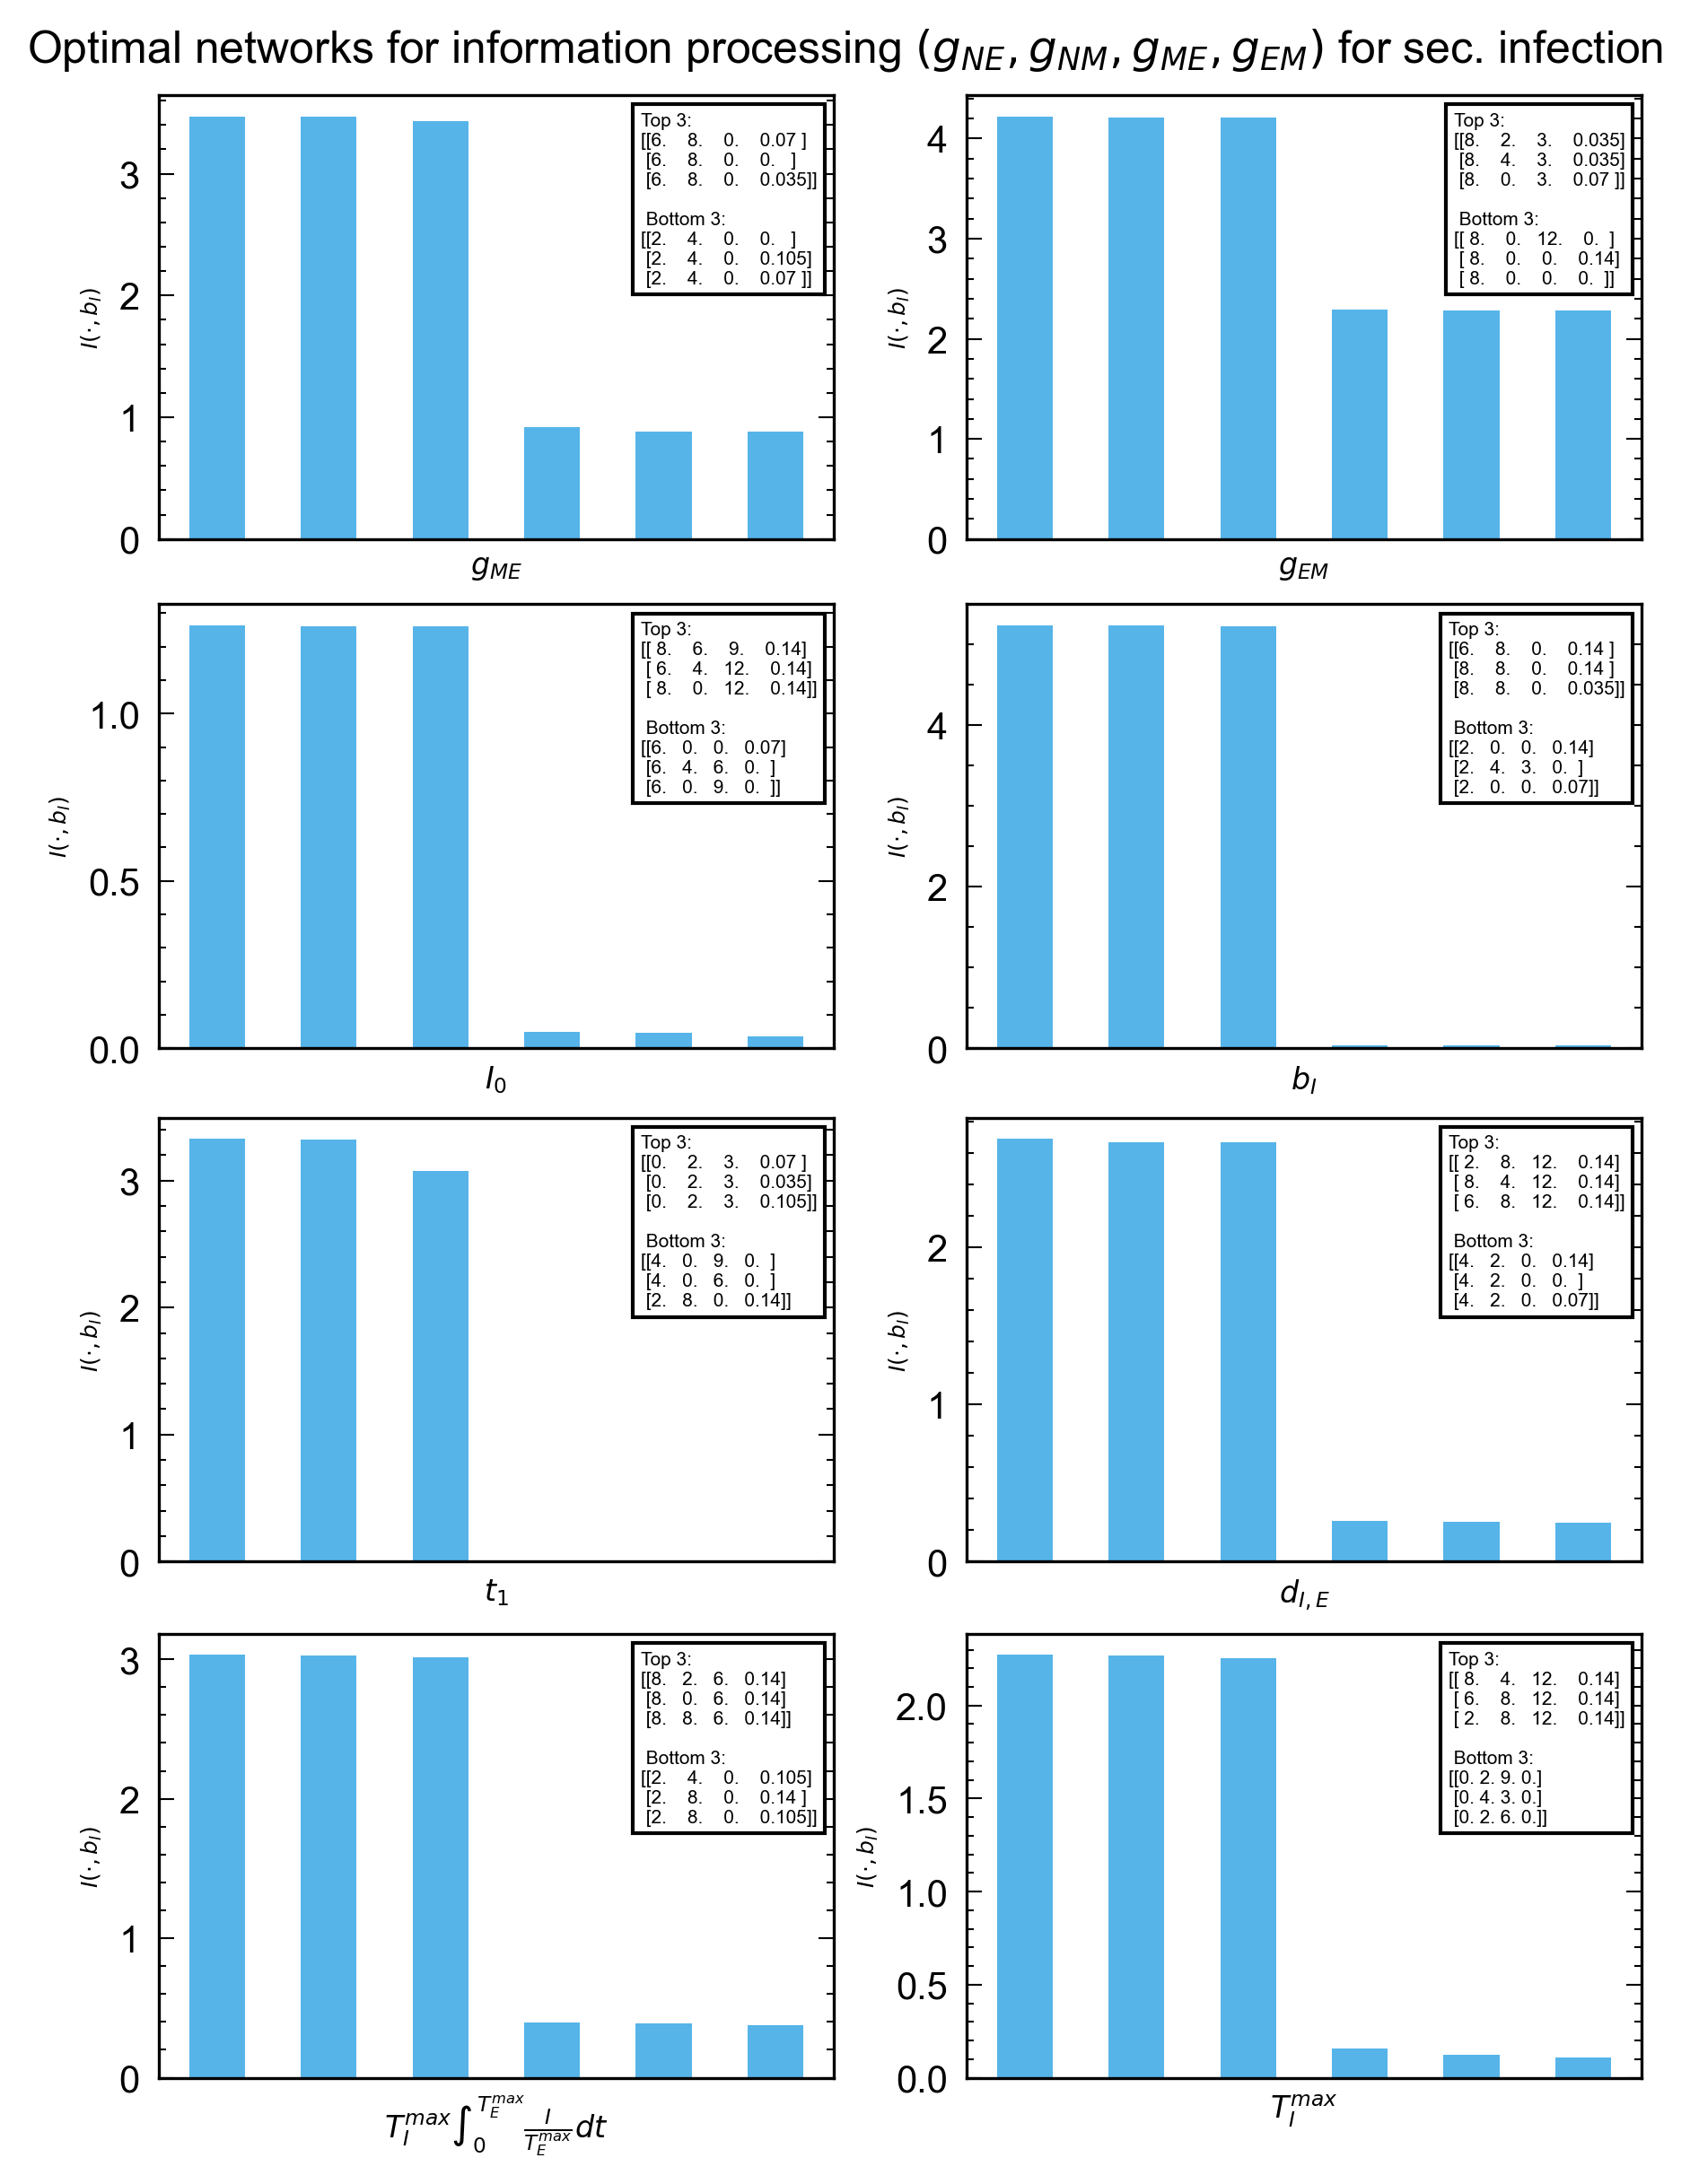

In [40]:
# Plot MI of networks
from matplotlib.offsetbox import AnchoredText
fig_networks, axs = plt.subplots(4,2, dpi = 150, constrained_layout = True, figsize = (6,8))
i = 4

for ax, val in zip(axs.flat,stat_names[i:]):
    
    rank_net = network_MI[(-network_MI[:, i]).argsort()]
    anchored_text = AnchoredText("Top 3: \n"+str(rank_net[:3,0:4])+"\n\n Bottom 3: \n"+str(rank_net[-4:-1,0:4]), 
                                 prop=dict(size=5), loc = "upper right")
    
    r = np.arange(6)
    width = 0.5
    ax.bar(r, np.append(rank_net[0:3,i], rank_net[-4:-1,i], axis = 0), width = width, label = r'vary $b_I$')

    ax.set_xlabel(val, fontsize = 8)
    ax.set_ylabel(r"$I(\cdot,b_I)$", fontsize = 6)
    ax.tick_params(
    axis='x',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
    ax.add_artist(anchored_text)
    
    #ax.set_title(plot_title, fontsize = 5)
    i += 1

    #ax.semilogy()
    #plt.legend()
fig_networks.suptitle(r'Optimal networks for information processing $(g_{NE},g_{NM},g_{ME},g_{EM})$'+' for '+infection_type+". infection")
fig_networks.savefig(infection_type+'-'+'rank-optimal-nets-for-info'+str(t1)+'.pdf', dpi=150)

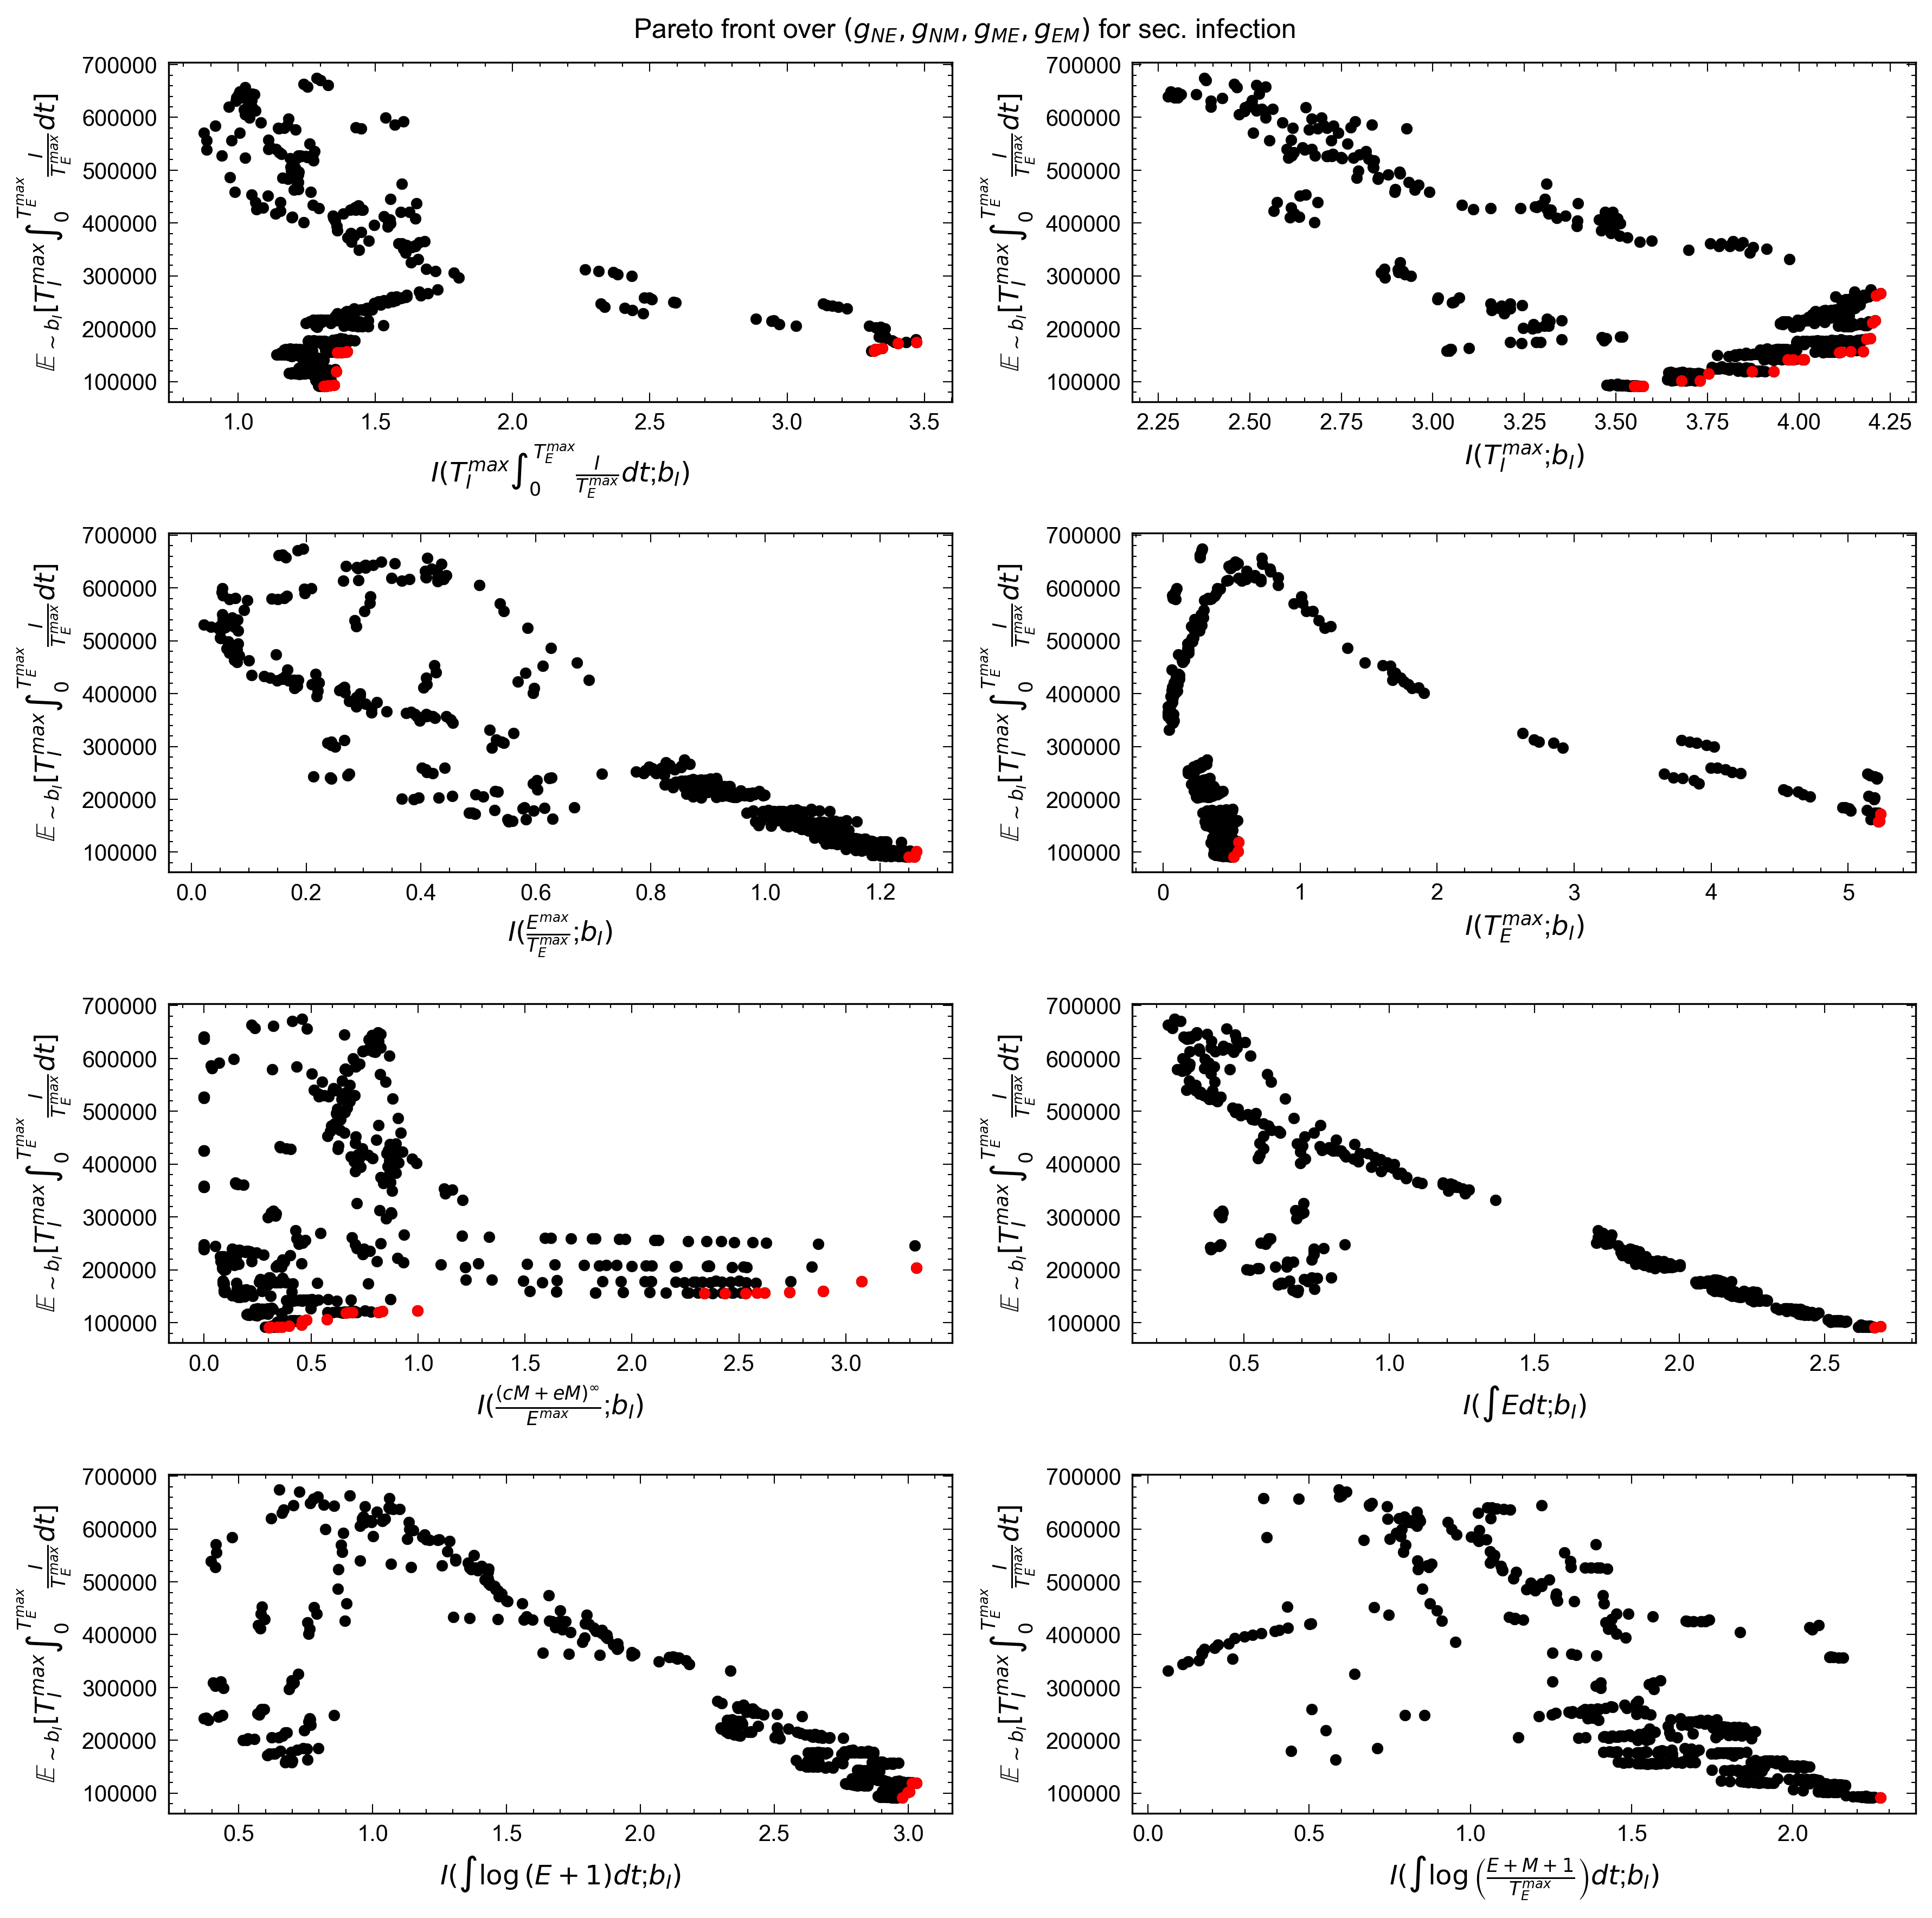

In [39]:
# plot pareto front for appropriateness and effectiveness of the immune response
fig_b_I = plt.figure(figsize=(12,12),dpi = 150)

i = 1

for val in stat_names[i+9:]:

    xy = np.array([np.nan_to_num(MI_data_no_zero[:,i], copy = False) ,np.nan_to_num(MI_data_no_zero[:,-1], copy = False)]).T
    
    # hull = ConvexHull(np.array([x_, y_]).T)
    
    ax = fig_b_I.add_subplot(4, 2, i)
    cs = ax.plot(xy[:,0], xy[:,1], 'ko')
    
    # find pareto front
    remove_row = np.ones(xy.shape[0], dtype = bool)
    
    for j in np.arange(len(xy[:,0])):
        for k in np.arange(len(xy[:,0])):
            if xy[j,0] < xy[k,0] and xy[j,1] > xy[k,1]:
                remove_row[j] = False
                
    
    x_front = (xy[:,0])[remove_row,...]
    y_front = (xy[:,1])[remove_row,...]
    ax.plot(x_front, y_front, 'ro')

    # set the limits of the plot to the limits of the data
    ax.set(xlabel=r"$I($"+val+r";$b_I)$", ylabel=r"$\mathbb{E}_{\sim b_I}[$"+stat_names[10]+r"$]$")

    i += 1
    
fig_b_I.suptitle(r'Pareto front over $(g_{NE},g_{NM},g_{ME},g_{EM})$'+' for '+infection_type+". infection")
fig_b_I.savefig(infection_type+'-pareto-over-all.pdf', dpi=300, bbox_inches="tight")
plt.tight_layout()

plt.show()

In [ ]:
# hull = ConvexHull(np.array([network_MI[:,-2], network_MI[:,-1]]).T)

# plt.plot(network_MI[:,-2], network_MI[:,-1], 'ko')
# for simplex in hull.simplices:
#     plt.plot(network_MI[simplex, -2], network_MI[simplex, -1], 'r-')
    
# plt.xlabel(r"$I($"+stat_names[-1]+r";$b_I)$")
# plt.ylabel(r"$\mathbb{E}_{\sim b_I}[$"+stat_names[4]+r"$]$")
# #plt.semilogy()
# plt.suptitle('Efficiency and cost for '+infection_type+". infection")
# #plt.savefig(infection_type+'-efficiency-and-cost.png', dpi=150, bbox_inches="tight")

### (6) Data visualization: Run PCA

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components = 3)
pca_result = pca.fit_transform(network_MI[:,:4])
print(pca.explained_variance_ratio_)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

img = ax.scatter(pca_result[:,0], pca_result[:,1], pca_result[:,2], c=network_MI[:,-1], cmap=plt.hot())
fig.colorbar(img)
plt.show()